In [2]:
# =========================================
# Step RR-1 · Candidate Union (K_cand=200)  —  Patched manifest parser
# =========================================
import os, json, gc
from pathlib import Path
import numpy as np
import pandas as pd

PARQUET_ENGINE = "fastparquet"
TMP_DIR = Path("./tmp").resolve()

# ---- 参数 ----
K_PER_VIEW   = 50           # 输入每图的K
K_CAND       = 200          # 候选上限
ROWS_PER_PART= 10_000       # 每片行数
SEED         = 123

# 输入前缀（对称化 + 行归一 + k=50）
PREF_TAG   = "S_tag_symrow_k50"
PREF_TEXT  = "S_text_symrow_k50"
PREF_BEH   = "S_beh_symrow_k50"
PREF_FUSE  = "S_fused3_symrow_k50"

# 输出前缀
OUT_PREF   = "S_fused3_rr_cand_k200"

np.random.seed(SEED)
print(f"[Env] TMP_DIR = {TMP_DIR}")

# ---------- 工具：稳健的类型转换 ----------
def _to_int(x, default=None):
    """把 x 转成 int；支持 str(含逗号)、float、list(取 len 或 sum)"""
    if x is None:
        return default
    if isinstance(x, (int, np.integer)):
        return int(x)
    if isinstance(x, float):
        return int(x)
    if isinstance(x, str):
        s = x.replace(",", "").replace("_","").strip()
        try:
            return int(float(s))
        except:
            return default
    if isinstance(x, list):
        # 常见两种：parts 为 list → 用 len；nnz 为 list → 用 sum
        # 但这里不知语义，交由调用处决定；这里返回 None 让上层处理
        return None
    return default

def read_manifest(prefix: str):
    man_path = TMP_DIR / f"{prefix}_manifest.json"
    if not man_path.exists():
        # 兼容早期命名
        cands = sorted(TMP_DIR.glob(f"{prefix}*_manifest.json"))
        if not cands:
            raise FileNotFoundError(f"[FATAL] manifest not found for prefix={prefix}")
        man_path = cands[0]

    with open(man_path, "r") as f:
        man = json.load(f)

    # nodes
    nodes = man.get("nodes", man.get("N", man.get("n", None)))
    n_val = _to_int(nodes)
    if n_val is None:
        # 尝试从 index_map 推断
        idmap_path = TMP_DIR / "index_map.parquet"
        if idmap_path.exists():
            id_map = pd.read_parquet(idmap_path, engine=PARQUET_ENGINE, columns=["doc_idx"])
            n_val = int(id_map["doc_idx"].max()) + 1
        else:
            # 最后兜底：从某个 part 文件中取最大 row/col
            part_files = sorted(TMP_DIR.glob(f"{prefix}_part*.parquet"))
            if not part_files:
                raise FileNotFoundError(f"[FATAL] cannot infer nodes, no part files for {prefix}")
            mx = 0
            for fp in part_files[:3]:
                df = pd.read_parquet(fp, engine=PARQUET_ENGINE, columns=["row","col"])
                mx = max(mx, int(df["row"].max()), int(df["col"].max()))
            n_val = mx + 1

    # parts
    parts = man.get("parts", None)
    p_val = _to_int(parts)
    files = man.get("files", None)
    if p_val is None:
        if isinstance(parts, list):
            p_val = len(parts)
        elif isinstance(files, list):
            p_val = len(files)
        else:
            # 扫描磁盘兜底
            p_val = len(sorted(TMP_DIR.glob(f"{prefix}_part*.parquet")))
            if p_val == 0:
                raise FileNotFoundError(f"[FATAL] no part files for {prefix}")

    # nnz（仅打印用，可为 None；若是列表则取 sum）
    nnz = man.get("nnz", man.get("total_edges", None))
    nnz_val = _to_int(nnz)
    if nnz_val is None and isinstance(nnz, list):
        try:
            nnz_val = int(sum([_to_int(x, 0) for x in nnz]))
        except:
            nnz_val = None

    # files（可选）
    if isinstance(files, list) and files:
        file_list = [str((TMP_DIR / fn).name if not str(fn).startswith(str(TMP_DIR)) else Path(fn).name)
                     for fn in files]
    else:
        file_list = []

    return {"nodes": int(n_val), "parts": int(p_val), "nnz": nnz_val, "files": file_list}

def list_part_files(prefix: str, manifest: dict):
    # 优先使用 manifest.files
    if manifest.get("files"):
        fps = [TMP_DIR / fn for fn in manifest["files"]]
        fps = [fp for fp in fps if fp.exists()]
        if fps:
            return fps
    # 否则按规则扫描
    fps = []
    for p in range(manifest["parts"]):
        fp = TMP_DIR / f"{prefix}_part{p:04d}.parquet"
        if fp.exists():
            fps.append(fp)
    if not fps:
        fps = sorted(TMP_DIR.glob(f"{prefix}_part*.parquet"))
    if not fps:
        raise FileNotFoundError(f"[FATAL] no part files for prefix={prefix}")
    return fps

# ---------- 两遍读构建 CSR ----------
def build_csr(prefix: str):
    man = read_manifest(prefix)
    N = man["nodes"]
    part_files = list_part_files(prefix, man)
    print(f"[LOAD] {prefix}: nodes={N:,}, parts={len(part_files)}, nnz≈{man['nnz'] if man['nnz'] else 'unknown'}")

    # pass-1: 计数
    counts = np.zeros(N, dtype=np.int64)
    for i, fp in enumerate(part_files, 1):
        df = pd.read_parquet(fp, engine=PARQUET_ENGINE, columns=["row"])
        r = df["row"].to_numpy(dtype=np.int64, copy=False)
        np.add.at(counts, r, 1)
        if i % 4 == 0 or i == len(part_files):
            print(f"[PASS1] {prefix} parts {i}/{len(part_files)} counted")
        del df
    indptr = np.zeros(N + 1, dtype=np.int64)
    np.cumsum(counts, out=indptr[1:])
    nnz = int(indptr[-1])
    indices = np.empty(nnz, dtype=np.int32)
    values  = np.empty(nnz, dtype=np.float32)
    write_ptr = indptr[:-1].copy()

    # pass-2: 填充
    for i, fp in enumerate(part_files, 1):
        df = pd.read_parquet(fp, engine=PARQUET_ENGINE, columns=["row","col","val"])
        rows = df["row"].to_numpy(np.int64,  copy=False)
        cols = df["col"].to_numpy(np.int32,  copy=False)
        vals = df["val"].to_numpy(np.float32, copy=False)
        order = np.argsort(rows, kind="stable")
        rows, cols, vals = rows[order], cols[order], vals[order]
        if len(rows) > 0:
            uniq_rows, start_idx = np.unique(rows, return_index=True)
            start_idx = np.r_[start_idx, len(rows)]
            for k in range(len(uniq_rows)):
                r = int(uniq_rows[k]); s, e = int(start_idx[k]), int(start_idx[k+1])
                wpos = write_ptr[r]
                ln = e - s
                indices[wpos:wpos+ln] = cols[s:e]
                values [wpos:wpos+ln] = vals[s:e]
                write_ptr[r] += ln
        if i % 4 == 0 or i == len(part_files):
            print(f"[PASS2] {prefix} parts {i}/{len(part_files)} filled")
        del df, rows, cols, vals, order
        gc.collect()
    return N, indptr, indices, values

# ---------- 读取四图为 CSR ----------
N_tag,  ip_tag,  ix_tag,  vx_tag  = build_csr(PREF_TAG)
N_text, ip_text, ix_text, vx_text = build_csr(PREF_TEXT)
N_beh,  ip_beh,  ix_beh,  vx_beh  = build_csr(PREF_BEH)
N_fus,  ip_fus,  ix_fus,  vx_fus  = build_csr(PREF_FUSE)
assert N_tag == N_text == N_beh == N_fus, "[FATAL] node size mismatch among views"
N = N_tag
print(f"[CSR] all views loaded. N={N:,}")

# ---------- 并集 + 标注 + 写分片 ----------
out_parts = 0
rows = np.arange(N, dtype=np.int64)
part_bounds = np.arange(0, N, ROWS_PER_PART, dtype=np.int64)
if part_bounds[-1] != N:
    part_bounds = np.r_[part_bounds, N]

out_files = []
for bi in range(len(part_bounds)-1):
    rs, re = int(part_bounds[bi]), int(part_bounds[bi+1])
    recs = []

    for r in range(rs, re):
        a = ix_tag [ip_tag [r]:ip_tag [r+1]]
        b = ix_text[ip_text[r]:ip_text[r+1]]
        c = ix_beh [ip_beh [r]:ip_beh [r+1]]
        d = ix_fus [ip_fus [r]:ip_fus [r+1]]

        cand = np.unique(np.concatenate((a,b,c,d)))
        if cand.size > K_CAND:
            dv = ix_fus[ip_fus[r]:ip_fus[r+1]]
            dw = vx_fus[ip_fus[r]:ip_fus[r+1]]
            base_score = np.zeros(cand.size, dtype=np.float32)
            if dv.size:
                # 简单线性查找即可；数组很小（<=200）
                for i, cj in enumerate(cand):
                    hit = np.where(dv == cj)[0]
                    base_score[i] = dw[int(hit[0])] if hit.size else 0.0
            take = np.argsort(-base_score, kind="stable")[:K_CAND]
            cand = cand[take]

        aset = set(a.tolist())
        bset = set(b.tolist())
        cset = set(c.tolist())
        dv   = ix_fus[ip_fus[r]:ip_fus[r+1]]
        dw   = vx_fus[ip_fus[r]:ip_fus[r+1]]
        fus_map = {int(dv[i]): float(dw[i]) for i in range(len(dv))}

        for j in cand:
            recs.append((
                int(r), int(j),
                1 if j in aset else 0,
                1 if j in bset else 0,
                1 if j in cset else 0,
                float(fus_map.get(int(j), 0.0))
            ))

    out_df = pd.DataFrame.from_records(
        recs, columns=["row","col","in_tag","in_text","in_beh","fused_base"]
    )
    out_fp = TMP_DIR / f"{OUT_PREF}_part{out_parts:04d}.parquet"
    out_df.to_parquet(out_fp, engine=PARQUET_ENGINE, index=False)
    out_files.append(str(out_fp.name))
    out_parts += 1
    print(f"[SAVE] part#{out_parts-1} rows={len(out_df):,} -> {out_fp.name}")
    del out_df, recs
    gc.collect()

man = {
    "nodes": int(N),
    "K_cand": int(K_CAND),
    "parts": int(out_parts),
    "source": {"tag": PREF_TAG, "text": PREF_TEXT, "beh": PREF_BEH, "fused": PREF_FUSE},
    "files": out_files
}
with open(TMP_DIR / f"{OUT_PREF}_manifest.json", "w") as f:
    json.dump(man, f)
print(f"[MANIFEST] {OUT_PREF}_manifest.json written. parts={out_parts}")
print("[STEP RR-1] DONE: candidate union built.")


[Env] TMP_DIR = /home/koyo/workspace/recsys/tmp
[LOAD] S_tag_symrow_k50: nodes=521,735, parts=15, nnz≈28159756
[PASS1] S_tag_symrow_k50 parts 4/15 counted
[PASS1] S_tag_symrow_k50 parts 8/15 counted
[PASS1] S_tag_symrow_k50 parts 12/15 counted
[PASS1] S_tag_symrow_k50 parts 15/15 counted
[PASS2] S_tag_symrow_k50 parts 4/15 filled
[PASS2] S_tag_symrow_k50 parts 8/15 filled
[PASS2] S_tag_symrow_k50 parts 12/15 filled
[PASS2] S_tag_symrow_k50 parts 15/15 filled
[LOAD] S_text_symrow_k50: nodes=521,735, parts=15, nnz≈28161106
[PASS1] S_text_symrow_k50 parts 4/15 counted
[PASS1] S_text_symrow_k50 parts 8/15 counted
[PASS1] S_text_symrow_k50 parts 12/15 counted
[PASS1] S_text_symrow_k50 parts 15/15 counted
[PASS2] S_text_symrow_k50 parts 4/15 filled
[PASS2] S_text_symrow_k50 parts 8/15 filled
[PASS2] S_text_symrow_k50 parts 12/15 filled
[PASS2] S_text_symrow_k50 parts 15/15 filled
[LOAD] S_beh_symrow_k50: nodes=521,735, parts=14, nnz≈26023186
[PASS1] S_beh_symrow_k50 parts 4/14 counted
[PASS1

In [1]:
# =========================================
# Step RR-2 · Rerank with support + light boosts + temperature softmax
# 输入:  tmp/S_fused3_rr_cand_k200_part*.parquet (+ manifest)
#        tmp/relevance_tag_docs.parquet, tmp/relevance_tag_idf.parquet
#        tmp/beh_base.parquet
# 输出:  tmp/S_fused3_rr_k50_part*.parquet + manifest
# =========================================
import json, gc
from pathlib import Path
import numpy as np
import pandas as pd

PARQUET_ENGINE = "fastparquet"
TMP_DIR = Path("./tmp").resolve()

# ---------- 可调参数 ----------
K_FINAL   = 50
TAU       = 1.5     # 温度（>1 压缩头部优势）
GAMMA     = 0.15    # support 一致性奖励权重
LAMBDA_TAG= 0.12    # Tag 重合 boost
LAMBDA_BEH= 0.08    # 行为轻吻合 boost
EPS       = 1e-8

CAND_PREF = "S_fused3_rr_cand_k200"  # RR-1 输出
OUT_PREF  = "S_fused3_rr_k50"        # 本步输出

print(f"[Env] TMP_DIR = {TMP_DIR}")

# ---------- 小工具 ----------
def _robust_minmax(x: np.ndarray):
    """按行做稳健 min-max 归一到 [0,1]（使用 5%~95% 分位裁剪，避免极端值）"""
    if x.size == 0:
        return x
    lo = np.quantile(x, 0.05) if x.size >= 20 else x.min()
    hi = np.quantile(x, 0.95) if x.size >= 20 else x.max()
    if hi - lo < 1e-12:
        return np.zeros_like(x, dtype=np.float32)
    x2 = np.clip(x, lo, hi)
    return ((x2 - lo) / (hi - lo)).astype(np.float32)

def _softmax_t(x: np.ndarray, tau: float):
    m = np.max(x)
    z = np.exp((x - m) / max(tau, 1e-6))
    s = z.sum()
    return (z / max(s, 1e-12)).astype(np.float32)

# ---------- 读取候选 manifest ----------
cand_man_path = TMP_DIR / f"{CAND_PREF}_manifest.json"
with open(cand_man_path, "r") as f:
    cand_man = json.load(f)
CAND_PARTS = cand_man.get("parts") or len(cand_man.get("files", []))
N_NODES    = int(cand_man.get("nodes"))
cand_files = cand_man.get("files")
if not cand_files:
    # 兜底：按规则扫描
    cand_files = [f"S_fused3_rr_cand_k200_part{p:04d}.parquet" for p in range(CAND_PARTS)]
print(f"[MAN] candidates: nodes={N_NODES:,}, parts={len(cand_files)}")

# ---------- 加载 Tag 侧缓存 ----------
tag_docs_path = TMP_DIR / "relevance_tag_docs.parquet"
tag_idf_path  = TMP_DIR / "relevance_tag_idf.parquet"
assert tag_docs_path.exists() and tag_idf_path.exists(), "[FATAL] tag relevance cache missing"

tag_docs = pd.read_parquet(tag_docs_path, engine=PARQUET_ENGINE)
# 支持 'tags' 或 'tag_list' 两种列名
if "tags" in tag_docs.columns:
    doc_tags_series = tag_docs.set_index("doc_idx")["tags"]
elif "tag_list" in tag_docs.columns:
    doc_tags_series = tag_docs.set_index("doc_idx")["tag_list"]
else:
    raise KeyError("[FATAL] relevance_tag_docs 缺少 tags/tag_list 列")
# 转为字典（只有有标签的文档会出现；其他默认为空集合）
doc2tags = {int(k): set(v) if isinstance(v, (list, set, tuple)) else set() 
            for k, v in doc_tags_series.items()}

tag_idf = pd.read_parquet(tag_idf_path, engine=PARQUET_ENGINE)
# 寻找 idf 的键列
idf_col = None
for c in ["tag","token","term","word","key"]:
    if c in tag_idf.columns:
        idf_col = c
        break
if idf_col is None:
    # 兼容以 'col' 存整数 id 的情况（不常见）
    if "col" in tag_idf.columns:
        # 这类通常与整数词表相配，此场景我们无法从字符串交集计算，退化为零 boost
        print("[WARN] tag_idf 使用整数索引，无法计算字面交集，将禁用 Tag 重合 boost。")
        LAMBDA_TAG = 0.0
        idf_map = {}
    else:
        raise KeyError("[FATAL] relevance_tag_idf 无法找到 tag 键列")
else:
    idf_map = {str(row[idf_col]): float(row["idf"]) for _, row in tag_idf.iterrows()}

# 为每个文档预存 denom = sum idf(tag)（无则 0）
denom_idf = np.zeros(N_NODES, dtype=np.float32)
for d, ts in doc2tags.items():
    if not ts:
        continue
    s = 0.0
    for t in ts:
        s += float(idf_map.get(str(t), 0.0))
    denom_idf[d] = s

print(f"[TAG] tag docs loaded: {len(doc2tags):,} docs with tags; idf entries={len(idf_map):,}")

# ---------- 加载行为基表 ----------
beh_base = pd.read_parquet(TMP_DIR / "beh_base.parquet", engine=PARQUET_ENGINE)
org_arr = np.full(N_NODES, -1, dtype=np.int64)
cre_arr = np.full(N_NODES, -1, dtype=np.int64)
bdx = beh_base["doc_idx"].to_numpy(np.int64)
if "OwnerOrganizationId" in beh_base.columns:
    orgv = beh_base["OwnerOrganizationId"].fillna(-1).astype("Int64").to_numpy()
else:
    orgv = np.full(bdx.size, -1, dtype="Int64")
if "CreatorUserId" in beh_base.columns:
    crev = beh_base["CreatorUserId"].fillna(-1).astype("Int64").to_numpy()
else:
    crev = np.full(bdx.size, -1, dtype="Int64")
org_arr[bdx] = np.array(orgv, dtype=np.int64)
cre_arr[bdx] = np.array(crev, dtype=np.int64)
print("[BEH] beh_base loaded.")

# ---------- 逐分片重排并落盘 ----------
out_files = []
for pi, fn in enumerate(cand_files, 1):
    fp = TMP_DIR / fn
    df = pd.read_parquet(fp, engine=PARQUET_ENGINE)
    # 期待列: row, col, in_tag, in_text, in_beh, fused_base
    assert {"row","col","in_tag","in_text","in_beh","fused_base"}.issubset(df.columns), \
        f"[FATAL] columns missing in {fn}"

    # 按 row 分组（每组 <= 200 候选）
    rows = df["row"].to_numpy(np.int64, copy=False)
    order = np.argsort(rows, kind="stable")
    rows_sorted = rows[order]
    cols_sorted = df["col"].to_numpy(np.int64, copy=False)[order]
    tagf = df["in_tag"].to_numpy(np.int32, copy=False)[order]
    textf= df["in_text"].to_numpy(np.int32, copy=False)[order]
    behf = df["in_beh"].to_numpy(np.int32, copy=False)[order]
    base = df["fused_base"].to_numpy(np.float32, copy=False)[order]

    uniq_rows, start_idx = np.unique(rows_sorted, return_index=True)
    start_idx = np.r_[start_idx, len(rows_sorted)]

    out_rec = []
    for k in range(len(uniq_rows)):
        r = int(uniq_rows[k])
        s, e = int(start_idx[k]), int(start_idx[k+1])

        cand_cols = cols_sorted[s:e].astype(np.int64, copy=False)
        support   = (tagf[s:e] + textf[s:e] + behf[s:e]).astype(np.int32, copy=False)
        fused_b   = base[s:e].astype(np.float32, copy=False)

        # 1) 一致性奖励
        s_cons = fused_b * (1.0 + GAMMA * np.maximum(0, support - 1))

        # 2) Tag 重合 IDF
        if LAMBDA_TAG > 0.0:
            tags_r = doc2tags.get(r, set())
            denom  = float(denom_idf[r]) + EPS
            st = np.zeros_like(fused_b, dtype=np.float32)
            if tags_r:
                # 逐候选做小集合交集（|tags| 平均≈2，开销极低）
                for i, j in enumerate(cand_cols):
                    tj = doc2tags.get(int(j), set())
                    if not tj:
                        continue
                    inter = tags_r.intersection(tj)
                    if not inter:
                        continue
                    s_idf = 0.0
                    for t in inter:
                        s_idf += float(idf_map.get(str(t), 0.0))
                    st[i] = s_idf / denom
            # 稳健归一
            st = _robust_minmax(st)
        else:
            st = np.zeros_like(fused_b, dtype=np.float32)

        # 3) 行为轻吻合（同 org / 同 creator；-1 视为缺失，不计匹配）
        org_r = org_arr[r]; cre_r = cre_arr[r]
        so = np.zeros_like(fused_b, dtype=np.float32)
        if org_r >= 0 or cre_r >= 0:
            org_j = org_arr[cand_cols]
            cre_j = cre_arr[cand_cols]
            hit_org = ((org_r >= 0) & (org_j >= 0) & (org_j == org_r)).astype(np.float32)
            hit_cre = ((cre_r >= 0) & (cre_j >= 0) & (cre_j == cre_r)).astype(np.float32)
            so = 0.5 * hit_org + 0.5 * hit_cre
        so = _robust_minmax(so)

        # 融合
        s_boost = s_cons + LAMBDA_TAG * st + LAMBDA_BEH * so

        # 温度 softmax & 选 Top-K
        prob = _softmax_t(s_boost, TAU)
        if prob.size > K_FINAL:
            take = np.argsort(-prob, kind="stable")[:K_FINAL]
            sel_c = cand_cols[take]
            sel_v = prob[take]
            # 行内归一，保证随机游走解释概率
            sel_v = (sel_v / max(sel_v.sum(), 1e-12)).astype(np.float32)
        else:
            sel_c = cand_cols
            sel_v = (prob / max(prob.sum(), 1e-12)).astype(np.float32)

        # 记录
        out_rec.extend([(r, int(c), float(v)) for c, v in zip(sel_c, sel_v)])

        if (k % 2000) == 0:
            print(f"[PROG] part {pi}/{len(cand_files)} row {k}/{len(uniq_rows)}")

    # 写分片
    out_df = pd.DataFrame(out_rec, columns=["row","col","val"])
    out_fp = TMP_DIR / f"{OUT_PREF}_part{pi-1:04d}.parquet"
    out_df.to_parquet(out_fp, engine=PARQUET_ENGINE, index=False)
    out_files.append(out_fp.name)
    print(f"[SAVE] {out_fp.name} edges={len(out_df):,}")
    del df, out_df, out_rec
    gc.collect()

# 写 manifest
man = {
    "nodes": int(N_NODES),
    "k": int(K_FINAL),
    "parts": int(len(out_files)),
    "files": out_files,
    "source_candidates": f"{CAND_PREF}_manifest.json",
    "params": {
        "tau": TAU, "gamma": GAMMA, "lambda_tag": LAMBDA_TAG, "lambda_beh": LAMBDA_BEH
    }
}
with open(TMP_DIR / f"{OUT_PREF}_manifest.json", "w") as f:
    json.dump(man, f)
print(f"[MANIFEST] {OUT_PREF}_manifest.json written. parts={len(out_files)}")
print("[STEP RR-2] DONE: reranked graph saved.")


[Env] TMP_DIR = /Users/koyo/workspace/recsys/tmp
[MAN] candidates: nodes=521,735, parts=53
[TAG] tag docs loaded: 521,735 docs with tags; idf entries=394
[BEH] beh_base loaded.
[PROG] part 1/53 row 0/10000
[PROG] part 1/53 row 2000/10000
[PROG] part 1/53 row 4000/10000
[PROG] part 1/53 row 6000/10000
[PROG] part 1/53 row 8000/10000
[SAVE] S_fused3_rr_k50_part0000.parquet edges=500,000
[PROG] part 2/53 row 0/10000
[PROG] part 2/53 row 2000/10000
[PROG] part 2/53 row 4000/10000
[PROG] part 2/53 row 6000/10000
[PROG] part 2/53 row 8000/10000
[SAVE] S_fused3_rr_k50_part0001.parquet edges=500,000
[PROG] part 3/53 row 0/10000
[PROG] part 3/53 row 2000/10000
[PROG] part 3/53 row 4000/10000
[PROG] part 3/53 row 6000/10000
[PROG] part 3/53 row 8000/10000
[SAVE] S_fused3_rr_k50_part0002.parquet edges=500,000
[PROG] part 4/53 row 0/10000
[PROG] part 4/53 row 2000/10000
[PROG] part 4/53 row 4000/10000
[PROG] part 4/53 row 6000/10000
[PROG] part 4/53 row 8000/10000
[SAVE] S_fused3_rr_k50_part0003.p

In [2]:
# =========================================
# Step RR-3 · Evaluate Fused3-RR @K=20 and append to tmp/metrics_main.csv
# 输入:  tmp/S_fused3_rr_k50_manifest.json + 分片
#       tmp/relevance_tag_docs.parquet, tmp/relevance_tag_idf.parquet
#       tmp/beh_base.parquet
# 输出:  在屏幕打印一行 DataFrame；追加写入 tmp/metrics_main.csv
# =========================================
import json, math
from pathlib import Path
import numpy as np
import pandas as pd

PARQUET_ENGINE = "fastparquet"
TMP_DIR = Path("./tmp").resolve()
PREF = "S_fused3_rr_k50"
K_EVAL = 20

W_TAG, W_ORG, W_CRE = 0.6, 0.1, 0.3  # 统一指标权重

print(f"[Env] TMP_DIR={TMP_DIR}")

# ---------- 读取 manifest ----------
man_path = TMP_DIR / f"{PREF}_manifest.json"
with open(man_path, "r") as f:
    man = json.load(f)
N = int(man["nodes"])
parts = man.get("parts") or len(man.get("files", []))
files = man.get("files")
if not files:
    files = [f"{PREF}_part{p:04d}.parquet" for p in range(parts)]
print(f"[MAN] {PREF}: nodes={N:,}, parts={len(files)}")

# ---------- 读取 Tag 银标缓存 ----------
tag_docs = pd.read_parquet(TMP_DIR/"relevance_tag_docs.parquet", engine=PARQUET_ENGINE)
# 支持 tags / tag_list 两种列名
if "tags" in tag_docs.columns:
    doc_tags_series = tag_docs.set_index("doc_idx")["tags"]
elif "tag_list" in tag_docs.columns:
    doc_tags_series = tag_docs.set_index("doc_idx")["tag_list"]
else:
    raise KeyError("[FATAL] relevance_tag_docs 缺少 tags/tag_list 列")
doc2tags = {int(k): (set(v) if isinstance(v, (list,set,tuple)) else set()) for k, v in doc_tags_series.items()}

tag_idf = pd.read_parquet(TMP_DIR/"relevance_tag_idf.parquet", engine=PARQUET_ENGINE)
idf_key = None
for c in ["tag","token","term","word","key"]:
    if c in tag_idf.columns: idf_key=c; break
if idf_key is None:
    raise KeyError("[FATAL] relevance_tag_idf 缺少可识别的键列")
idf_map = {str(r[idf_key]): float(r["idf"]) for _, r in tag_idf.iterrows()}

# 预备：每文档标签 IDF 和；每标签文档计数（用于 Tag-Recall 分母的上界近似）
denom_idf = np.zeros(N, dtype=np.float32)
tag_freq = {}
for d, ts in doc2tags.items():
    s = 0.0
    for t in ts:
        s += float(idf_map.get(str(t), 0.0))
        tag_freq[t] = tag_freq.get(t, 0) + 1
    denom_idf[d] = s
tag_cov_docs = len(doc2tags)
print(f"[TAG] docs_with_tags={tag_cov_docs:,} / {N:,} ({tag_cov_docs/N:.3%}), idf_size={len(idf_map)}")

# ---------- 读取行为基表（Org/Creator 银标） ----------
beh = pd.read_parquet(TMP_DIR/"beh_base.parquet", engine=PARQUET_ENGINE)
org_arr = np.full(N, -1, dtype=np.int64)
cre_arr = np.full(N, -1, dtype=np.int64)
idx = beh["doc_idx"].to_numpy(np.int64)
if "OwnerOrganizationId" in beh.columns:
    orgv = beh["OwnerOrganizationId"].fillna(-1).astype("Int64").to_numpy()
else:
    orgv = np.full(idx.size, -1, dtype="Int64")
if "CreatorUserId" in beh.columns:
    crev = beh["CreatorUserId"].fillna(-1).astype("Int64").to_numpy()
else:
    crev = np.full(idx.size, -1, dtype="Int64")
org_arr[idx] = np.array(orgv, dtype=np.int64)
cre_arr[idx] = np.array(crev, dtype=np.int64)

# 组规模（用于 Recall 分母）
def group_sizes(arr: np.ndarray):
    # 仅统计 >=0 的 id
    ids, cnts = np.unique(arr[arr>=0], return_counts=True)
    return dict(zip(ids.tolist(), cnts.tolist()))
org_size = group_sizes(org_arr)
cre_size = group_sizes(cre_arr)

# ---------- 指标累加器 ----------
def zero_metrics():
    return dict(ndcg=0.0, ap=0.0, rr=0.0, p=0.0, r=0.0, covered=0, total=0)

m_tag = zero_metrics()
m_org = zero_metrics()
m_cre = zero_metrics()

# 预先计算 IDCG@K（上界：每位增益视为1）
IDCG = sum([1.0 / math.log2(r+2) for r in range(K_EVAL)])

def update_binary_metrics(m, rel_flags):
    """rel_flags: 长度<=K 的 0/1 numpy 向量（按排名）"""
    if rel_flags.size == 0:
        return
    K = rel_flags.size
    # P@K
    prec = rel_flags.sum() / float(K)
    # R@K: 需要在外部传入分母，外层处理
    # AP@K
    if rel_flags.sum() > 0:
        ranks = np.where(rel_flags>0)[0]  # 0-based ranks
        prec_at_hits = [(rel_flags[:(r+1)].sum() / float(r+1)) for r in ranks]
        ap = float(np.mean(prec_at_hits))
        rr = 1.0 / float(ranks[0]+1)
    else:
        ap = 0.0; rr = 0.0
    m["ap"] += ap
    m["rr"] += rr
    m["p"]  += prec

def update_ndcg(m, gains):
    """gains: 长度<=K 的 [0,1] 归一增益"""
    if gains.size == 0:
        return
    dcg = float(np.sum(gains / np.log2(np.arange(gains.size)+2)))
    m["ndcg"] += (dcg / IDCG)

def finalize(m):
    tot = max(m["total"], 1)
    return dict(
        nDCG = m["ndcg"]/tot,
        MAP  = m["ap"]/tot,
        MRR  = m["rr"]/tot,
        P    = m["p"]/tot,
        R    = m["r"]/tot,
        Coverage = m["covered"]/tot
    )

# ---------- 逐分片评测 ----------
for pi, fn in enumerate(files, 1):
    df = pd.read_parquet(TMP_DIR/fn, engine=PARQUET_ENGINE)
    # 期望列: row,col,val（本步已是 Top-50，且行内已归一）
    rows = df["row"].to_numpy(np.int64, copy=False)
    cols = df["col"].to_numpy(np.int64, copy=False)
    vals = df["val"].to_numpy(np.float32, copy=False)

    order = np.argsort(rows, kind="stable")
    rows, cols, vals = rows[order], cols[order], vals[order]
    uniq_rows, start = np.unique(rows, return_index=True)
    start = np.r_[start, len(rows)]

    for k in range(len(uniq_rows)):
        r = int(uniq_rows[k]); s, e = int(start[k]), int(start[k+1])
        # Top-K=20
        take = slice(s, min(s+K_EVAL, e))
        nbrs = cols[take]
        # ------- Tag -------
        tags_r = doc2tags.get(r, set())
        if tags_r:
            # 归一化增益（基于 IDF）
            denom = float(denom_idf[r]) + 1e-8
            gains = np.zeros(nbrs.size, dtype=np.float32)
            flags = np.zeros(nbrs.size, dtype=np.int32)
            for i, j in enumerate(nbrs):
                tj = doc2tags.get(int(j), set())
                if not tj: continue
                inter = tags_r.intersection(tj)
                if not inter: continue
                flags[i] = 1
                s_idf = 0.0
                for t in inter:
                    s_idf += float(idf_map.get(str(t), 0.0))
                gains[i] = min(1.0, s_idf/denom)
            # recall 分母（上界近似）
            denom_rec = 0
            for t in tags_r:
                denom_rec += max(0, tag_freq.get(t,0)-1)
            # 累加
            m_tag["covered"] += 1
            m_tag["total"]   += 1
            update_ndcg(m_tag, gains)
            update_binary_metrics(m_tag, flags)
            if denom_rec > 0:
                m_tag["r"] += float(flags.sum())/float(denom_rec)
        else:
            m_tag["total"] += 1  # 计入 coverage 分母

        # ------- Org -------
        org_r = org_arr[r]
        if org_r >= 0:
            flags = (org_arr[nbrs] == org_r).astype(np.int32)
            m_org["covered"] += 1
            m_org["total"]   += 1
            update_binary_metrics(m_org, flags)
            denom = max(1, org_size.get(int(org_r), 0) - 1)
            m_org["r"] += float(flags.sum())/float(denom)
            # nDCG：二值增益
            update_ndcg(m_org, flags.astype(np.float32))
        else:
            m_org["total"] += 1

        # ------- Creator -------
        cre_r = cre_arr[r]
        if cre_r >= 0:
            flags = (cre_arr[nbrs] == cre_r).astype(np.int32)
            m_cre["covered"] += 1
            m_cre["total"]   += 1
            update_binary_metrics(m_cre, flags)
            denom = max(1, cre_size.get(int(cre_r), 0) - 1)
            m_cre["r"] += float(flags.sum())/float(denom)
            update_ndcg(m_cre, flags.astype(np.float32))
        else:
            m_cre["total"] += 1

    if (pi % 4) == 0 or pi == len(files):
        print(f"[EVAL] processed {pi}/{len(files)} parts")

# ---------- 汇总并写表 ----------
res_tag = finalize(m_tag)
res_org = finalize(m_org)
res_cre = finalize(m_cre)

row = {
    "method": "Fused3-RR",
    # Tag
    "Tag-nDCG@20": res_tag["nDCG"], "Tag-MAP@20": res_tag["MAP"], "Tag-MRR@20": res_tag["MRR"],
    "Tag-P@20": res_tag["P"], "Tag-R@20": res_tag["R"], "Tag-Coverage": res_tag["Coverage"],
    # Org
    "Org-nDCG@20": res_org["nDCG"], "Org-MAP@20": res_org["MAP"], "Org-MRR@20": res_org["MRR"],
    "Org-P@20": res_org["P"], "Org-R@20": res_org["R"], "Org-Coverage": res_org["Coverage"],
    # Creator
    "Creator-nDCG@20": res_cre["nDCG"], "Creator-MAP@20": res_cre["MAP"], "Creator-MRR@20": res_cre["MRR"],
    "Creator-P@20": res_cre["P"], "Creator-R@20": res_cre["R"], "Creator-Coverage": res_cre["Coverage"],
}

# 统一指标（加权）
row["Unified@nDCG20"]      = W_TAG*row["Tag-nDCG@20"] + W_ORG*row["Org-nDCG@20"] + W_CRE*row["Creator-nDCG@20"]
row["Unified_cov@nDCG20"]  = W_TAG*row["Tag-Coverage"] + W_ORG*row["Org-Coverage"] + W_CRE*row["Creator-Coverage"]

out_df = pd.DataFrame([row])
print("\n[RESULT] Fused3-RR @K=20")
display(out_df)

# 追加写入 csv
csv_path = TMP_DIR/"metrics_main.csv"
if csv_path.exists():
    base = pd.read_csv(csv_path)
    base = pd.concat([base, out_df], ignore_index=True)
    base.to_csv(csv_path, index=False)
else:
    out_df.to_csv(csv_path, index=False)
print(f"[SAVE] appended to {csv_path}")


[Env] TMP_DIR=/Users/koyo/workspace/recsys/tmp
[MAN] S_fused3_rr_k50: nodes=521,735, parts=53
[TAG] docs_with_tags=521,735 / 521,735 (100.000%), idf_size=394
[EVAL] processed 4/53 parts
[EVAL] processed 8/53 parts
[EVAL] processed 12/53 parts
[EVAL] processed 16/53 parts
[EVAL] processed 20/53 parts
[EVAL] processed 24/53 parts
[EVAL] processed 28/53 parts
[EVAL] processed 32/53 parts
[EVAL] processed 36/53 parts
[EVAL] processed 40/53 parts
[EVAL] processed 44/53 parts
[EVAL] processed 48/53 parts
[EVAL] processed 52/53 parts
[EVAL] processed 53/53 parts

[RESULT] Fused3-RR @K=20


,method,Tag-nDCG@20,Tag-MAP@20,Tag-MRR@20,Tag-P@20,Tag-R@20,Tag-Coverage,Org-nDCG@20,Org-MAP@20,Org-MRR@20,...,Org-R@20,Org-Coverage,Creator-nDCG@20,Creator-MAP@20,Creator-MRR@20,Creator-P@20,Creator-R@20,Creator-Coverage,Unified@nDCG20,Unified_cov@nDCG20
0,Fused3-RR,0.088108,0.187412,0.191586,0.127827,0.000203,0.411291,0.003627,0.004318,0.004384,...,0.001829,0.004943,0.39409,0.734146,0.73949,0.319931,0.622271,1.0,0.171455,0.547269


[SAVE] appended to /Users/koyo/workspace/recsys/tmp/metrics_main.csv


In [5]:
# =========================================
# Step RR-BLEND-1 (fixed v2) · Build S_fused3_blend_eta020_k50
# 读:  tmp/S_fused3_symrow_k50_manifest.json + 分片
#     tmp/S_fused3_rr_k50_manifest.json + 分片
# 写:  tmp/S_fused3_blend_eta020_k50_partXXXX.parquet + manifest
# =========================================
import json
from pathlib import Path
import numpy as np
import pandas as pd

PARQUET_ENGINE = "fastparquet"
TMP_DIR = Path("./tmp").resolve()

PREF_RA = "S_fused3_symrow_k50"   # 行自适应融合（RA）
PREF_RR = "S_fused3_rr_k50"       # rerank 后的图（RR）

ETA = 0.20                 # 融合权重: 20% RR + 80% RA
TOPK = 50
FLUSH_EDGES = 2_000_000    # 每分片写出边数（近似）
OUT_PREF = f"S_fused3_blend_eta{int(ETA*100):03d}_k{TOPK:02d}"

print(f"[Env] TMP_DIR={TMP_DIR}")
print(f"[CFG] Blend: (1-eta)*RA + eta*RR, eta={ETA}, K={TOPK}")

def _read_manifest(prefix: str):
    """兼容多种 manifest 结构：
       - {"nodes":int, "parts":int, "nnz":int, "files":[...]}  (推荐)
       - {"nodes":int, "parts":[file,...], "nnz":int}          (parts 直接是文件名列表)
       - {"nodes":int, "parts":int}                            (无 files，用 parts 数构造默认文件名)
    """
    mp = TMP_DIR / f"{prefix}_manifest.json"
    with open(mp, "r") as f:
        man = json.load(f)

    nodes = man.get("nodes") or man.get("N") or man.get("docs")
    if nodes is None:
        raise ValueError(f"[FATAL] manifest {mp} 缺少 'nodes'")
    nodes = int(nodes)

    files = man.get("files")
    if not files:
        parts_field = man.get("parts")
        if isinstance(parts_field, list):
            files = parts_field
        elif isinstance(parts_field, (int, float, str)):
            parts_int = int(parts_field)
            files = [f"{prefix}_part{p:04d}.parquet" for p in range(parts_int)]
        else:
            files = sorted([p.name for p in TMP_DIR.glob(f"{prefix}_part*.parquet")])
            if not files:
                raise ValueError(f"[FATAL] 无法从 manifest 推断分片文件: {mp}")

    nnz = man.get("nnz") or man.get("total_edges")
    if isinstance(nnz, list):
        nnz = int(sum(int(x) for x in nnz))
    elif nnz is not None:
        nnz = int(nnz)

    return nodes, files, nnz

def _csr_from_parts(prefix: str):
    """两遍扫描将行随机图加载成 CSR（indptr, indices, values）"""
    N, files, _ = _read_manifest(prefix)

    # pass1: 行计数
    counts = np.zeros(N, dtype=np.int64)
    for i, fn in enumerate(files, 1):
        df = pd.read_parquet(TMP_DIR / fn, engine=PARQUET_ENGINE)
        r = df["row"].to_numpy(np.int64, copy=False)
        uniq, cnt = np.unique(r, return_counts=True)
        counts[uniq] += cnt
        if (i % 4) == 0 or i == len(files):
            print(f"[PASS1] {prefix} parts {i}/{len(files)} counted")

    indptr = np.zeros(N + 1, dtype=np.int64)
    np.cumsum(counts, out=indptr[1:])
    nnz = int(indptr[-1])

    indices = np.empty(nnz, dtype=np.int32)
    values  = np.empty(nnz, dtype=np.float32)
    cursor  = indptr.copy()

    # pass2: 填充
    for i, fn in enumerate(files, 1):
        df = pd.read_parquet(TMP_DIR / fn, engine=PARQUET_ENGINE)
        r = df["row"].to_numpy(np.int64, copy=False)
        c = df["col"].to_numpy(np.int64, copy=False).astype(np.int32, copy=False)
        v = df["val"].to_numpy(np.float32, copy=False)

        order = np.argsort(r, kind="stable")
        r, c, v = r[order], c[order], v[order]

        uniq, start = np.unique(r, return_index=True)
        start = np.r_[start, len(r)]
        for k in range(len(uniq)):
            rr = int(uniq[k]); s, e = int(start[k]), int(start[k + 1])
            pos = cursor[rr]; n = e - s
            indices[pos:pos + n] = c[s:e]
            values[pos:pos + n]  = v[s:e]
            cursor[rr] += n

        if (i % 4) == 0 or i == len(files):
            print(f"[PASS2] {prefix} parts {i}/{len(files)} filled")

    return N, indptr, indices, values

# ---------- 加载 RA 与 RR ----------
N_ra, ip_ra, ix_ra, vx_ra = _csr_from_parts(PREF_RA)
N_rr, ip_rr, ix_rr, vx_rr = _csr_from_parts(PREF_RR)
assert N_ra == N_rr, "[FATAL] N mismatch"
N = N_ra
print(f"[CSR] loaded both graphs. N={N:,}, RA_nnz={ip_ra[-1]:,}, RR_nnz={ip_rr[-1]:,}")

# ---------- 行融合 + TopK + 归一 ----------
out_rows, out_cols, out_vals = [], [], []
edges_in_buffer, part_idx = 0, 0

def _flush():
    """把缓冲边写出为一个分片，并清空缓冲。"""
    global out_rows, out_cols, out_vals, edges_in_buffer, part_idx
    if not out_rows:
        return
    df = pd.DataFrame({
        "row": np.asarray(out_rows, dtype=np.int64),
        "col": np.asarray(out_cols, dtype=np.int64),
        "val": np.asarray(out_vals, dtype=np.float32),
    })
    fn = f"{OUT_PREF}_part{part_idx:04d}.parquet"
    df.to_parquet(TMP_DIR / fn, engine=PARQUET_ENGINE, index=False)
    print(f"[SAVE] {fn} edges={len(df)}")
    part_idx += 1
    out_rows.clear(); out_cols.clear(); out_vals.clear()
    edges_in_buffer = 0

for r in range(N):
    s1, e1 = ip_ra[r], ip_ra[r+1]
    s2, e2 = ip_rr[r], ip_rr[r+1]

    pool = {}
    if e1 > s1:
        for p in range(s1, e1):
            j = int(ix_ra[p])
            pool[j] = pool.get(j, 0.0) + (1.0 - ETA) * float(vx_ra[p])
    if e2 > s2:
        for p in range(s2, e2):
            j = int(ix_rr[p])
            pool[j] = pool.get(j, 0.0) + ETA * float(vx_rr[p])

    if not pool:
        continue

    items = list(pool.items())
    if len(items) > TOPK:
        sel = np.argpartition([-w for _, w in items], TOPK-1)[:TOPK]
        items = [items[i] for i in sel]

    cols = np.array([j for j, _ in items], dtype=np.int64)
    vals = np.array([w for _, w in items], dtype=np.float32)
    s = float(vals.sum())
    if s > 0:
        vals /= s
    order = np.argsort(-vals, kind="stable")
    cols, vals = cols[order], vals[order]

    out_rows.extend([r]*len(cols))
    out_cols.extend(cols.tolist())
    out_vals.extend(vals.tolist())
    edges_in_buffer += len(cols)

    if edges_in_buffer >= FLUSH_EDGES:
        _flush()

    if (r+1) % 200_000 == 0:
        print(f"[PROG] rows processed {r+1:,}/{N:,}")

_flush()

# ---------- 写 manifest ----------
part_files = [f"{OUT_PREF}_part{p:04d}.parquet" for p in range(part_idx)]
nnz_sum = 0
for fn in part_files:
    nnz_sum += pd.read_parquet(TMP_DIR / fn, engine=PARQUET_ENGINE).shape[0]

man = {"nodes": int(N), "parts": part_files, "nnz": int(nnz_sum), "files": part_files}
with open(TMP_DIR / f"{OUT_PREF}_manifest.json", "w") as f:
    json.dump(man, f)

print(f"[MANIFEST] {OUT_PREF}_manifest.json  parts={len(part_files)}, nnz≈{nnz_sum:,}")
print("[Step RR-BLEND-1] DONE: blended graph generated.")


[Env] TMP_DIR=/Users/koyo/workspace/recsys/tmp
[CFG] Blend: (1-eta)*RA + eta*RR, eta=0.2, K=50
[PASS1] S_fused3_symrow_k50 parts 4/14 counted
[PASS1] S_fused3_symrow_k50 parts 8/14 counted
[PASS1] S_fused3_symrow_k50 parts 12/14 counted
[PASS1] S_fused3_symrow_k50 parts 14/14 counted
[PASS2] S_fused3_symrow_k50 parts 4/14 filled
[PASS2] S_fused3_symrow_k50 parts 8/14 filled
[PASS2] S_fused3_symrow_k50 parts 12/14 filled
[PASS2] S_fused3_symrow_k50 parts 14/14 filled
[PASS1] S_fused3_rr_k50 parts 4/53 counted
[PASS1] S_fused3_rr_k50 parts 8/53 counted
[PASS1] S_fused3_rr_k50 parts 12/53 counted
[PASS1] S_fused3_rr_k50 parts 16/53 counted
[PASS1] S_fused3_rr_k50 parts 20/53 counted
[PASS1] S_fused3_rr_k50 parts 24/53 counted
[PASS1] S_fused3_rr_k50 parts 28/53 counted
[PASS1] S_fused3_rr_k50 parts 32/53 counted
[PASS1] S_fused3_rr_k50 parts 36/53 counted
[PASS1] S_fused3_rr_k50 parts 40/53 counted
[PASS1] S_fused3_rr_k50 parts 44/53 counted
[PASS1] S_fused3_rr_k50 parts 48/53 counted
[PA

In [6]:
# =========================================
# Step RR-BLEND-2 · 评测混合图 (η=0.20) 并追加到 metrics_main.csv
# 读:  tmp/S_fused3_blend_eta020_k50_manifest.json + 分片
#     tmp/relevance_tag_docs.parquet, tmp/relevance_tag_idf.parquet
#     tmp/relevance_org.parquet, tmp/relevance_creator.parquet
# 写:  tmp/metrics_main.csv （追加）
# =========================================
import json
from pathlib import Path
import numpy as np
import pandas as pd

PARQUET_ENGINE = "fastparquet"
TMP_DIR = Path("./tmp").resolve()

# ---- 评测设置 ----
GRAPH_PREF   = "S_fused3_blend_eta020_k50"
METHOD_NAME  = "Fused3-Blend-eta0.20"
K_EVAL       = 20

# 统一指标权重（已与你确认的 0.6 / 0.1 / 0.3）
W_TAG, W_ORG, W_CRE = 0.6, 0.1, 0.3

print(f"[Env] TMP_DIR={TMP_DIR}")
print(f"[CFG] Evaluate {METHOD_NAME} @K={K_EVAL}")

# ---------- 读取混合图 manifest ----------
with open(TMP_DIR / f"{GRAPH_PREF}_manifest.json","r") as f:
    man = json.load(f)
nodes = int(man.get("nodes"))
parts = man.get("files") or man.get("parts")
if isinstance(parts, int):
    part_files = [f"{GRAPH_PREF}_part{p:04d}.parquet" for p in range(parts)]
elif isinstance(parts, list):
    part_files = parts
else:
    part_files = sorted([p.name for p in TMP_DIR.glob(f"{GRAPH_PREF}_part*.parquet")])
print(f"[MAN] {GRAPH_PREF}: nodes={nodes:,}, parts={len(part_files)}")

# ---------- 读取银标 ----------
# Tag：每文档标签列表（list[str]），以及 tag 的 idf 可选（这里仅用于后续扩展；当前用二值相关一致口径）
tag_docs_df = pd.read_parquet(TMP_DIR / "relevance_tag_docs.parquet", engine=PARQUET_ENGINE)
N_docs = int(tag_docs_df["doc_idx"].max()) + 1
assert N_docs == nodes, f"[FATAL] node size mismatch: tags N={N_docs} vs graph N={nodes}"

# 将标签列表放入定长数组（缺失为空列表）
tag_lists = [None] * nodes
for r in tag_docs_df.itertuples(index=False):
    idx = int(r.doc_idx)
    # r.tags 可能是 list[str] 或逗号串，统一成 set[str]
    tags = r.tags
    if isinstance(tags, str):
        tags = [t.strip() for t in tags.split(",") if t.strip()]
    tag_lists[idx] = set(tags) if tags else set()
tag_docs_df = None  # 释放

# 构建 tag 倒排（用于估计每个查询的 N_rel 以求 IDCG）
tag2docs = {}
for i, s in enumerate(tag_lists):
    if not s:
        continue
    for t in s:
        tag2docs.setdefault(t, []).append(i)
for t in list(tag2docs.keys()):
    tag2docs[t] = np.asarray(tag2docs[t], dtype=np.int64)

# Org / Creator：单一标签（-1 表示缺失）
org_df = pd.read_parquet(TMP_DIR / "relevance_org.parquet", engine=PARQUET_ENGINE)
creator_df = pd.read_parquet(TMP_DIR / "relevance_creator.parquet", engine=PARQUET_ENGINE)

org_arr = np.full(nodes, -1, dtype=np.int64)
org_arr[org_df["doc_idx"].to_numpy(np.int64)] = org_df["org_id"].to_numpy(np.int64)
creator_arr = np.full(nodes, -1, dtype=np.int64)
creator_arr[creator_df["doc_idx"].to_numpy(np.int64)] = creator_df["creator_id"].to_numpy(np.int64)

# 统计每个 org / creator 的文档数（用于 N_rel）
org_counts = pd.Series(org_arr).value_counts().to_dict()
creator_counts = pd.Series(creator_arr).value_counts().to_dict()

# ---------- 指标工具 ----------
LOG2 = np.log(2.0)
def dcg_at_k(rel):
    # rel 为 0/1 的 ndarray，长度 <= K
    if rel.size == 0:
        return 0.0
    idx = np.arange(1, rel.size + 1, dtype=np.float64)
    return np.sum(rel / np.log2(idx + 1.0))

def idcg_at_k(n_rel, k):
    m = int(min(n_rel, k))
    if m <= 0:
        return 0.0
    idx = np.arange(1, m + 1, dtype=np.float64)
    return np.sum(1.0 / np.log2(idx + 1.0))

def ap_at_k(rel):
    # 0/1 relevance，AP@K = Σ precision@i (在每个命中位置 i) / min(K, N_rel)
    if rel.size == 0:
        return 0.0
    hits = np.where(rel == 1)[0]
    if hits.size == 0:
        return 0.0
    precs = [(i+1) / (hit+1) for i, hit in enumerate(hits)]
    denom = max(1, min(rel.size, int(rel.sum())))  # min(K, N_rel)
    return float(np.sum(precs) / denom)

def rr_at_k(rel):
    hits = np.where(rel == 1)[0]
    return float(1.0/(hits[0]+1)) if hits.size > 0 else 0.0

# ---------- 评测累加器 ----------
# 对每一种任务，仅在“可评估”的行内取均值，并单独给出 Coverage（可评估行 / 全体）
tag_cov_cnt = 0
tag_ndcg_sum = tag_map_sum = tag_mrr_sum = tag_p_sum = tag_r_sum = 0.0

org_cov_cnt = 0
org_ndcg_sum = org_map_sum = org_mrr_sum = org_p_sum = org_r_sum = 0.0

creator_cov_cnt = 0
creator_ndcg_sum = creator_map_sum = creator_mrr_sum = creator_p_sum = creator_r_sum = 0.0

def eval_one_row(q, neigh):
    """neigh: ndarray[int] 预测的 top-K 邻居（不含排序权）"""
    global tag_cov_cnt, tag_ndcg_sum, tag_map_sum, tag_mrr_sum, tag_p_sum, tag_r_sum
    global org_cov_cnt, org_ndcg_sum, org_map_sum, org_mrr_sum, org_p_sum, org_r_sum
    global creator_cov_cnt, creator_ndcg_sum, creator_map_sum, creator_mrr_sum, creator_p_sum, creator_r_sum

    K = min(K_EVAL, neigh.size)
    if K == 0:
        return
    neigh = neigh[:K]

    # -------- Tag 评测（二值相关：是否有共享标签；IDCG 依据查询的真实 N_rel）
    q_tags = tag_lists[q]
    if q_tags and len(q_tags) > 0:
        tag_cov_cnt += 1
        # 计算 N_rel（全集中与 q 共享任一 tag 的文档数，排除自身）
        cand_union = None
        for t in q_tags:
            arr = tag2docs.get(t)
            if arr is None: 
                continue
            cand_union = arr if cand_union is None else np.union1d(cand_union, arr)
        if cand_union is None:
            n_rel = 0
        else:
            n_rel = int(cand_union.size - (1 if q in set(cand_union.tolist()) else 0))

        # 邻居二值相关
        rel = np.zeros(K, dtype=np.int8)
        if len(q_tags) > 0:
            # 更高效：把 q_tags 转为局部 set，逐一判断
            qset = q_tags
            for i, j in enumerate(neigh):
                tj = tag_lists[int(j)]
                rel[i] = 1 if (tj and len(qset.intersection(tj)) > 0) else 0

        # nDCG / MAP / MRR / P / R
        nd = 0.0
        idc = idcg_at_k(n_rel, K_EVAL)
        if idc > 0:
            nd = dcg_at_k(rel) / idc
        tag_ndcg_sum += nd
        tag_map_sum  += ap_at_k(rel)
        tag_mrr_sum  += rr_at_k(rel)
        tag_p_sum    += float(rel.sum()) / K_EVAL
        tag_r_sum    += (float(rel.sum()) / max(1, n_rel)) if n_rel > 0 else 0.0

    # -------- Org 评测（同 Org）
    q_org = int(org_arr[q])
    if q_org != -1 and org_counts.get(q_org, 0) > 1:
        org_cov_cnt += 1
        n_rel = org_counts[q_org] - 1
        rel = (org_arr[neigh] == q_org).astype(np.int8, copy=False)

        idc = idcg_at_k(n_rel, K_EVAL)
        nd  = (dcg_at_k(rel) / idc) if idc > 0 else 0.0
        org_ndcg_sum += nd
        org_map_sum  += ap_at_k(rel)
        org_mrr_sum  += rr_at_k(rel)
        org_p_sum    += float(rel.sum()) / K_EVAL
        org_r_sum    += (float(rel.sum()) / max(1, n_rel)) if n_rel > 0 else 0.0

    # -------- Creator 评测（同 Creator）
    q_cr = int(creator_arr[q])
    if q_cr != -1 and creator_counts.get(q_cr, 0) > 1:
        creator_cov_cnt += 1
        n_rel = creator_counts[q_cr] - 1
        rel = (creator_arr[neigh] == q_cr).astype(np.int8, copy=False)

        idc = idcg_at_k(n_rel, K_EVAL)
        nd  = (dcg_at_k(rel) / idc) if idc > 0 else 0.0
        creator_ndcg_sum += nd
        creator_map_sum  += ap_at_k(rel)
        creator_mrr_sum  += rr_at_k(rel)
        creator_p_sum    += float(rel.sum()) / K_EVAL
        creator_r_sum    += (float(rel.sum()) / max(1, n_rel)) if n_rel > 0 else 0.0

# ---------- 流式评测 ----------
ROWS_PER_PRINT = 200_000
rows_done = 0

for pi, fn in enumerate(part_files, 1):
    df = pd.read_parquet(TMP_DIR / fn, engine=PARQUET_ENGINE)
    # 假定每分片内已按 row 聚合；保险起见还是 groupby
    for r, grp in df.groupby("row"):
        neigh = grp.sort_values("val", ascending=False)["col"].to_numpy(np.int64, copy=False)
        eval_one_row(int(r), neigh)
        rows_done += 1
        if (rows_done % ROWS_PER_PRINT) == 0:
            print(f"[EVAL] processed {rows_done:,}/{nodes:,} rows")
    print(f"[PART] {pi}/{len(part_files)} done")

# ---------- 汇总 & 写出 ----------
eps = 1e-12
tag_cov_rate     = tag_cov_cnt / nodes
org_cov_rate     = org_cov_cnt / nodes
creator_cov_rate = creator_cov_cnt / nodes

def safe_mean(s, n): 
    return (s / max(1, n))

row = {
    "method": METHOD_NAME,
    "Tag-nDCG@20":     safe_mean(tag_ndcg_sum,     tag_cov_cnt),
    "Tag-MAP@20":      safe_mean(tag_map_sum,      tag_cov_cnt),
    "Tag-MRR@20":      safe_mean(tag_mrr_sum,      tag_cov_cnt),
    "Tag-P@20":        safe_mean(tag_p_sum,        tag_cov_cnt),
    "Tag-R@20":        safe_mean(tag_r_sum,        tag_cov_cnt),
    "Tag-Coverage":    tag_cov_rate,

    "Org-nDCG@20":     safe_mean(org_ndcg_sum,     org_cov_cnt),
    "Org-MAP@20":      safe_mean(org_map_sum,      org_cov_cnt),
    "Org-MRR@20":      safe_mean(org_mrr_sum,      org_cov_cnt),
    "Org-P@20":        safe_mean(org_p_sum,        org_cov_cnt),
    "Org-R@20":        safe_mean(org_r_sum,        org_cov_cnt),
    "Org-Coverage":    org_cov_rate,

    "Creator-nDCG@20": safe_mean(creator_ndcg_sum, creator_cov_cnt),
    "Creator-MAP@20":  safe_mean(creator_map_sum,  creator_cov_cnt),
    "Creator-MRR@20":  safe_mean(creator_mrr_sum,  creator_cov_cnt),
    "Creator-P@20":    safe_mean(creator_p_sum,    creator_cov_cnt),
    "Creator-R@20":    safe_mean(creator_r_sum,    creator_cov_cnt),
    "Creator-Coverage":creator_cov_rate,
}

# 统一指标（按你指定的 0.6/0.1/0.3）
row["Unified@nDCG20"]      = W_TAG*row["Tag-nDCG@20"] + W_ORG*row["Org-nDCG@20"] + W_CRE*row["Creator-nDCG@20"]
row["Unified_cov@nDCG20"]  = W_TAG*(row["Tag-nDCG@20"]*row["Tag-Coverage"]) \
                           + W_ORG*(row["Org-nDCG@20"]*row["Org-Coverage"]) \
                           + W_CRE*(row["Creator-nDCG@20"]*row["Creator-Coverage"])

out_df = pd.DataFrame([row])
csv_path = TMP_DIR / "metrics_main.csv"
if csv_path.exists():
    base = pd.read_csv(csv_path)
    base = pd.concat([base, out_df], axis=0, ignore_index=True)
    base.to_csv(csv_path, index=False)
else:
    out_df.to_csv(csv_path, index=False)

display(out_df.round(6))
print(f"[SAVE] appended to {csv_path}")


[Env] TMP_DIR=/Users/koyo/workspace/recsys/tmp
[CFG] Evaluate Fused3-Blend-eta0.20 @K=20
[MAN] S_fused3_blend_eta020_k50: nodes=521,735, parts=14
[PART] 1/14 done
[PART] 2/14 done
[PART] 3/14 done
[PART] 4/14 done
[EVAL] processed 200,000/521,735 rows
[PART] 5/14 done
[PART] 6/14 done
[PART] 7/14 done
[PART] 8/14 done
[PART] 9/14 done
[EVAL] processed 400,000/521,735 rows
[PART] 10/14 done
[PART] 11/14 done
[PART] 12/14 done
[PART] 13/14 done
[PART] 14/14 done


,method,Tag-nDCG@20,Tag-MAP@20,Tag-MRR@20,Tag-P@20,Tag-R@20,Tag-Coverage,Org-nDCG@20,Org-MAP@20,Org-MRR@20,...,Org-R@20,Org-Coverage,Creator-nDCG@20,Creator-MAP@20,Creator-MRR@20,Creator-P@20,Creator-R@20,Creator-Coverage,Unified@nDCG20,Unified_cov@nDCG20
0,Fused3-Blend-eta0.20,0.197454,0.360188,0.367804,0.170117,0.000342,0.411291,0.693488,0.742792,0.718254,...,0.366986,0.004504,0.890474,0.896391,0.877651,0.375943,0.799523,0.7759,0.454963,0.256315


[SAVE] appended to /Users/koyo/workspace/recsys/tmp/metrics_main.csv


In [7]:
# =========================================
# Step RR-BLEND-GRID · η 网格融合 + 评测（一次跑全）
# 读:  tmp/S_fused3_symrow_k50_*.parquet + manifest (RA)
#     tmp/S_fused3_rr_k50_*.parquet      + manifest (RR)
#     tmp/relevance_tag_docs.parquet / relevance_org.parquet / relevance_creator.parquet
# 写:  tmp/S_fused3_blend_etaXXX_k50_part*.parquet + manifest
#     tmp/metrics_main.csv (追加)
# =========================================
import json, math, gc
from pathlib import Path
import numpy as np
import pandas as pd

PARQUET_ENGINE = "fastparquet"
TMP_DIR = Path("./tmp").resolve()
ETAS = [0.10, 0.15, 0.20, 0.25, 0.30]
K_KEEP = 50
K_EVAL = 20
W_TAG, W_ORG, W_CRE = 0.6, 0.1, 0.3

print(f"[Env] TMP_DIR={TMP_DIR}")

# ---------- 基础工具 ----------
def _read_manifest(prefix: str):
    man = json.load(open(TMP_DIR / f"{prefix}_manifest.json","r"))
    nodes = int(man["nodes"])
    files = man.get("files")
    if files is None:
        parts = man.get("parts")
        if isinstance(parts, int):
            files = [f"{prefix}_part{p:04d}.parquet" for p in range(parts)]
        else:
            files = sorted([p.name for p in TMP_DIR.glob(f"{prefix}_part*.parquet")])
    return nodes, files

def _iter_rows(prefix: str):
    """逐分片读取 (row,col,val)，yield (row -> [col,val] 排序后数组) 的迭代器"""
    nodes, files = _read_manifest(prefix)
    for fn in files:
        df = pd.read_parquet(TMP_DIR / fn, engine=PARQUET_ENGINE)
        for r, grp in df.groupby("row"):
            g = grp.sort_values("val", ascending=False)
            yield int(r), g["col"].to_numpy(np.int64, copy=False), g["val"].to_numpy(np.float32, copy=False)
        del df
        gc.collect()
    return

def _blend_and_save(eta: float, pref_ra: str, pref_rr: str, out_pref: str):
    """(1-eta)*RA + eta*RR，行内取 top-K_KEEP，流式写分片 + manifest"""
    nodes_ra, files_ra = _read_manifest(pref_ra)
    nodes_rr, files_rr = _read_manifest(pref_rr)
    assert nodes_ra == nodes_rr, "[FATAL] node mismatch RA vs RR"
    N = nodes_ra
    print(f"[BLEND] eta={eta:.2f} | N={N:,} | K={K_KEEP}")

    # 逐行双指针融合（两来源已各自按 val 降序）
    # 为避免大量内存占用，我们按若干万行 flush 到磁盘
    BUF_ROWS = []
    CHUNK_ROWS = 200_000
    part_idx = 0
    rows_seen = 0

    # 为加速：将 RR 分片建一个 row->(cols,vals) 的临时映射（分批），避免全量驻留
    # 简化处理：我们同步遍历两份分片生成的迭代器，以行为键做归并
    it_ra = _iter_rows(pref_ra)
    it_rr = _iter_rows(pref_rr)
    cur_ra = next(it_ra, None)
    cur_rr = next(it_rr, None)

    def flush():
        nonlocal part_idx, BUF_ROWS
        if not BUF_ROWS:
            return
        out_df = pd.concat(BUF_ROWS, axis=0, ignore_index=True)
        out_df.to_parquet(TMP_DIR / f"{out_pref}_part{part_idx:04d}.parquet",
                          engine=PARQUET_ENGINE, index=False)
        print(f"[SAVE] {out_pref}_part{part_idx:04d}.parquet rows={len(out_df):,}")
        part_idx += 1
        BUF_ROWS = []

    while cur_ra is not None or cur_rr is not None:
        if cur_ra is None:
            r = cur_rr[0]
        elif cur_rr is None:
            r = cur_ra[0]
        else:
            r = min(cur_ra[0], cur_rr[0])

        cols = []
        vals = []

        if cur_ra is not None and cur_ra[0] == r:
            _, c_ra, v_ra = cur_ra
            cols.append(c_ra); vals.append((1.0-eta)*v_ra)
            cur_ra = next(it_ra, None)
        if cur_rr is not None and cur_rr[0] == r:
            _, c_rr, v_rr = cur_rr
            cols.append(c_rr); vals.append(eta*v_rr)
            cur_rr = next(it_rr, None)

        if cols:
            C = np.concatenate(cols)
            V = np.concatenate(vals)
            # 合并重复 col
            order = np.argsort(C, kind="mergesort")
            C = C[order]; V = V[order]
            # reduce by key
            uniq, starts = np.unique(C, return_index=True)
            sums = np.add.reduceat(V, starts)
            # 降序取前 K
            top = np.argsort(-sums)[:K_KEEP]
            C_top = uniq[top]; V_top = sums[top]
            # 写入缓冲
            BUF_ROWS.append(pd.DataFrame({
                "row": np.full(C_top.size, r, dtype=np.int64),
                "col": C_top.astype(np.int64, copy=False),
                "val": V_top.astype(np.float32, copy=False),
            }))
        rows_seen += 1
        if rows_seen % CHUNK_ROWS == 0:
            flush()
            print(f"[PROG] blended rows={rows_seen:,}/{N:,}")

    # 最后一批
    flush()
    # 写 manifest
    man = {"nodes": N, "parts": part_idx}
    json.dump(man, open(TMP_DIR / f"{out_pref}_manifest.json","w"))
    print(f"[MANIFEST] {out_pref}_manifest.json parts={part_idx}")

# ---------- 评测工具（与前一步一致口径） ----------
LOG2 = np.log(2.0)
def dcg_at_k(rel):
    if rel.size == 0: return 0.0
    idx = np.arange(1, rel.size + 1, dtype=np.float64)
    return float(np.sum(rel / np.log2(idx + 1.0)))

def idcg_at_k(n_rel, k):
    m = int(min(n_rel, k))
    if m <= 0: return 0.0
    idx = np.arange(1, m + 1, dtype=np.float64)
    return float(np.sum(1.0 / np.log2(idx + 1.0)))

def ap_at_k(rel):
    if rel.size == 0: return 0.0
    hits = np.where(rel == 1)[0]
    if hits.size == 0: return 0.0
    precs = [(i+1) / (hit+1) for i, hit in enumerate(hits)]
    denom = max(1, min(rel.size, int(rel.sum())))
    return float(np.sum(precs) / denom)

def rr_at_k(rel):
    hits = np.where(rel == 1)[0]
    return float(1.0/(hits[0]+1)) if hits.size>0 else 0.0

def eval_graph(prefix: str, method_name: str):
    nodes, files = _read_manifest(prefix)

    # Tag 银标
    tag_docs_df = pd.read_parquet(TMP_DIR / "relevance_tag_docs.parquet", engine=PARQUET_ENGINE)
    assert int(tag_docs_df["doc_idx"].max())+1 == nodes
    tag_lists = [set() for _ in range(nodes)]
    for r in tag_docs_df.itertuples(index=False):
        tags = r.tags
        if isinstance(tags, str):
            tags = [t.strip() for t in tags.split(",") if t.strip()]
        tag_lists[int(r.doc_idx)] = set(tags) if tags else set()
    tag2docs = {}
    for i,s in enumerate(tag_lists):
        for t in s:
            tag2docs.setdefault(t, []).append(i)
    for t in list(tag2docs):
        tag2docs[t] = np.asarray(tag2docs[t], dtype=np.int64)

    # Org / Creator 银标
    org_df = pd.read_parquet(TMP_DIR / "relevance_org.parquet", engine=PARQUET_ENGINE)
    creator_df = pd.read_parquet(TMP_DIR / "relevance_creator.parquet", engine=PARQUET_ENGINE)
    org_arr = np.full(nodes, -1, dtype=np.int64)
    org_arr[org_df["doc_idx"].to_numpy(np.int64)] = org_df["org_id"].to_numpy(np.int64)
    creator_arr = np.full(nodes, -1, dtype=np.int64)
    creator_arr[creator_df["doc_idx"].to_numpy(np.int64)] = creator_df["creator_id"].to_numpy(np.int64)
    org_counts = pd.Series(org_arr).value_counts().to_dict()
    creator_counts = pd.Series(creator_arr).value_counts().to_dict()

    # 累加器
    tag_cov=org_cov=creator_cov = 0
    tag_nd=tag_ap=tag_rr=tag_p=tag_r = 0.0
    org_nd=org_ap=org_rr=org_p=org_r = 0.0
    cr_nd=cr_ap=cr_rr=cr_p=cr_r = 0.0

    rows_done=0
    for pi, fn in enumerate(files, 1):
        df = pd.read_parquet(TMP_DIR / fn, engine=PARQUET_ENGINE)
        for r, grp in df.groupby("row"):
            arr = grp.sort_values("val", ascending=False)["col"].to_numpy(np.int64, copy=False)[:K_EVAL]
            # Tag
            qtags = tag_lists[r]
            if qtags:
                tag_cov += 1
                # N_rel
                cand = None
                for t in qtags:
                    a = tag2docs.get(t)
                    cand = a if cand is None else np.union1d(cand, a)
                n_rel = 0 if cand is None else int(cand.size - (1 if r in set(cand.tolist()) else 0))
                rel = np.array([(len(tag_lists[j].intersection(qtags))>0) for j in arr], dtype=np.int8)
                idc = idcg_at_k(n_rel, K_EVAL)
                tag_nd += (dcg_at_k(rel)/idc) if idc>0 else 0.0
                tag_ap += ap_at_k(rel)
                tag_rr += rr_at_k(rel)
                tag_p  += float(rel.sum())/K_EVAL
                tag_r  += (float(rel.sum())/max(1,n_rel)) if n_rel>0 else 0.0

            # Org
            q_org = org_arr[r]
            if q_org != -1 and org_counts.get(q_org,0)>1:
                org_cov += 1
                n_rel = org_counts[q_org]-1
                rel = (org_arr[arr]==q_org).astype(np.int8)
                idc = idcg_at_k(n_rel, K_EVAL)
                org_nd += (dcg_at_k(rel)/idc) if idc>0 else 0.0
                org_ap += ap_at_k(rel)
                org_rr += rr_at_k(rel)
                org_p  += float(rel.sum())/K_EVAL
                org_r  += (float(rel.sum())/max(1,n_rel)) if n_rel>0 else 0.0

            # Creator
            q_cr = creator_arr[r]
            if q_cr != -1 and creator_counts.get(q_cr,0)>1:
                creator_cov += 1
                n_rel = creator_counts[q_cr]-1
                rel = (creator_arr[arr]==q_cr).astype(np.int8)
                idc = idcg_at_k(n_rel, K_EVAL)
                cr_nd += (dcg_at_k(rel)/idc) if idc>0 else 0.0
                cr_ap += ap_at_k(rel)
                cr_rr += rr_at_k(rel)
                cr_p  += float(rel.sum())/K_EVAL
                cr_r  += (float(rel.sum())/max(1,n_rel)) if n_rel>0 else 0.0

            rows_done += 1
        print(f"[EVAL] {prefix} parts {pi}/{len(files)} processed")

    def mean(x, n): return x/max(1,n)
    row = {
        "method": method_name,
        "Tag-nDCG@20":     mean(tag_nd, tag_cov),
        "Tag-MAP@20":      mean(tag_ap, tag_cov),
        "Tag-MRR@20":      mean(tag_rr, tag_cov),
        "Tag-P@20":        mean(tag_p,  tag_cov),
        "Tag-R@20":        mean(tag_r,  tag_cov),
        "Tag-Coverage":    tag_cov / nodes,

        "Org-nDCG@20":     mean(org_nd, org_cov),
        "Org-MAP@20":      mean(org_ap, org_cov),
        "Org-MRR@20":      mean(org_rr, org_cov),
        "Org-P@20":        mean(org_p,  org_cov),
        "Org-R@20":        mean(org_r,  org_cov),
        "Org-Coverage":    org_cov / nodes,

        "Creator-nDCG@20": mean(cr_nd,  creator_cov),
        "Creator-MAP@20":  mean(cr_ap,  creator_cov),
        "Creator-MRR@20":  mean(cr_rr,  creator_cov),
        "Creator-P@20":    mean(cr_p,   creator_cov),
        "Creator-R@20":    mean(cr_r,   creator_cov),
        "Creator-Coverage":creator_cov / nodes,
    }
    row["Unified@nDCG20"]     = W_TAG*row["Tag-nDCG@20"] + W_ORG*row["Org-nDCG@20"] + W_CRE*row["Creator-nDCG@20"]
    row["Unified_cov@nDCG20"] = W_TAG*(row["Tag-nDCG@20"]*row["Tag-Coverage"]) \
                              + W_ORG*(row["Org-nDCG@20"]*row["Org-Coverage"]) \
                              + W_CRE*(row["Creator-nDCG@20"]*row["Creator-Coverage"])
    return pd.DataFrame([row])

# ---------- 主流程：对每个 η 融合+评测 ----------
pref_ra = "S_fused3_symrow_k50"
pref_rr = "S_fused3_rr_k50"
all_rows = []

for eta in ETAS:
    out_pref = f"S_fused3_blend_eta{int(round(eta*100)):03d}_k50"
    _blend_and_save(eta, pref_ra, pref_rr, out_pref)
    df = eval_graph(out_pref, f"Fused3-Blend-eta{eta:.2f}")
    all_rows.append(df)
    # 追加到 metrics_main.csv
    csv_path = TMP_DIR / "metrics_main.csv"
    if csv_path.exists():
        base = pd.read_csv(csv_path)
        base = pd.concat([base, df], axis=0, ignore_index=True)
        base.to_csv(csv_path, index=False)
    else:
        df.to_csv(csv_path, index=False)

# 汇总展示
summary = pd.concat(all_rows, axis=0, ignore_index=True)
display(summary.sort_values("Unified@nDCG20", ascending=False).round(6))
print("[DONE] blend grid finished & metrics appended.")


[Env] TMP_DIR=/Users/koyo/workspace/recsys/tmp
[BLEND] eta=0.10 | N=521,735 | K=50
[SAVE] S_fused3_blend_eta010_k50_part0000.parquet rows=10,000,000
[PROG] blended rows=200,000/521,735
[SAVE] S_fused3_blend_eta010_k50_part0001.parquet rows=10,000,000
[PROG] blended rows=400,000/521,735
[SAVE] S_fused3_blend_eta010_k50_part0002.parquet rows=6,086,750
[MANIFEST] S_fused3_blend_eta010_k50_manifest.json parts=3
[EVAL] S_fused3_blend_eta010_k50 parts 1/3 processed
[EVAL] S_fused3_blend_eta010_k50 parts 2/3 processed
[EVAL] S_fused3_blend_eta010_k50 parts 3/3 processed
[BLEND] eta=0.15 | N=521,735 | K=50
[SAVE] S_fused3_blend_eta015_k50_part0000.parquet rows=10,000,000
[PROG] blended rows=200,000/521,735
[SAVE] S_fused3_blend_eta015_k50_part0001.parquet rows=10,000,000
[PROG] blended rows=400,000/521,735
[SAVE] S_fused3_blend_eta015_k50_part0002.parquet rows=6,086,750
[MANIFEST] S_fused3_blend_eta015_k50_manifest.json parts=3
[EVAL] S_fused3_blend_eta015_k50 parts 1/3 processed
[EVAL] S_fuse

,method,Tag-nDCG@20,Tag-MAP@20,Tag-MRR@20,Tag-P@20,Tag-R@20,Tag-Coverage,Org-nDCG@20,Org-MAP@20,Org-MRR@20,...,Org-R@20,Org-Coverage,Creator-nDCG@20,Creator-MAP@20,Creator-MRR@20,Creator-P@20,Creator-R@20,Creator-Coverage,Unified@nDCG20,Unified_cov@nDCG20
4,Fused3-Blend-eta0.30,0.213326,0.373912,0.377555,0.185165,0.000356,0.411291,0.719696,0.776366,0.745488,...,0.370922,0.004504,0.894420,0.900423,0.882302,0.379246,0.800029,0.7759,0.468291,0.261162
3,Fused3-Blend-eta0.25,0.210140,0.369008,0.372595,0.182988,0.000353,0.411291,0.707074,0.758616,0.730155,...,0.369235,0.004504,0.892456,0.898209,0.879825,0.377643,0.799783,0.7759,0.464528,0.259913
2,Fused3-Blend-eta0.20,0.197412,0.360309,0.367793,0.170051,0.000341,0.411291,0.693488,0.742792,0.718254,...,0.366986,0.004504,0.890391,0.895995,0.877213,0.375898,0.799520,0.7759,0.454914,0.256285
1,Fused3-Blend-eta0.15,0.191324,0.355583,0.362587,0.164236,0.000334,0.411291,0.679836,0.727857,0.705578,...,0.364500,0.004504,0.887831,0.893298,0.872997,0.373956,0.799223,0.7759,0.449127,0.254180
0,Fused3-Blend-eta0.10,0.186179,0.348192,0.355937,0.160532,0.000329,0.411291,0.664227,0.712756,0.694489,...,0.361297,0.004504,0.883838,0.889059,0.866470,0.371101,0.798738,0.7759,0.443281,0.251974


[DONE] blend grid finished & metrics appended.


In [1]:
# ==== Config ====
import os, glob, json, math
import numpy as np
import pandas as pd

# 自动适配你的环境路径（优先使用你在之前脚本里设置的 TMP_DIR）
TMP_DIR = os.environ.get("TMP_DIR", "/home/koyo/workspace/recsys/tmp")
if not os.path.isdir(TMP_DIR):
    cand = "/Users/koyo/workspace/recsys/tmp"  # macOS 日志中出现过
    if os.path.isdir(cand):
        TMP_DIR = cand
print("[CFG] TMP_DIR =", TMP_DIR)

# ==== Load metrics*.csv ====
def load_metrics(tmp_dir: str) -> pd.DataFrame:
    files = sorted(glob.glob(os.path.join(tmp_dir, "metrics*.csv")))
    assert files, f"[FATAL] 未找到 {tmp_dir}/metrics*.csv"
    frames = []
    for f in files:
        try:
            df = pd.read_csv(f)
            if "method" in df.columns:
                frames.append(df)
                print(f"[LOAD] {os.path.basename(f)} rows={len(df)}")
        except Exception as e:
            print(f"[WARN] 读取失败: {f} ({e})")
    assert frames, "[FATAL] 没有可用的 metrics CSV"
    out = pd.concat(frames, ignore_index=True)
    out = out.drop_duplicates(subset=["method"], keep="last").reset_index(drop=True)
    print(f"[MERGE] methods={out['method'].nunique()}, rows={len(out)}")
    return out

metrics_df = load_metrics(TMP_DIR)

# 统一补齐可能缺失的列，保证绘图逻辑稳定
expected_cols = [
    "Tag-nDCG@20","Tag-MAP@20","Tag-MRR@20","Tag-P@20","Tag-R@20","Tag-Coverage",
    "Org-nDCG@20","Org-MAP@20","Org-MRR@20","Org-P@20","Org-R@20","Org-Coverage",
    "Creator-nDCG@20","Creator-MAP@20","Creator-MRR@20","Creator-P@20","Creator-R@20","Creator-Coverage",
    "Unified@nDCG20","Unified_cov@nDCG20"
]
for c in expected_cols:
    if c not in metrics_df.columns:
        metrics_df[c] = np.nan
print("[OK] columns ready.")


[CFG] TMP_DIR = /home/koyo/workspace/recsys/tmp
[LOAD] metrics_all.csv rows=10
[LOAD] metrics_baselines_A.csv rows=2
[LOAD] metrics_baselines_B.csv rows=2
[LOAD] metrics_fusion_baselines.csv rows=2
[LOAD] metrics_main.csv rows=11
[LOAD] metrics_main_v2.csv rows=4
[LOAD] metrics_main_with_unified.csv rows=4
[MERGE] methods=16, rows=16
[OK] columns ready.


In [2]:
import matplotlib.pyplot as plt

def group_filter(df: pd.DataFrame, group: str) -> pd.DataFrame:
    if group == "tag":
        m = df["method"].astype(str).str.startswith("Tag-")
    elif group == "text":
        m = df["method"].astype(str).str.startswith("Text-")
    elif group == "fusion":
        m = df["method"].astype(str).str.startswith(("Fused","Fusion-"))
    else:
        raise ValueError("unknown group")
    out = df[m].copy().reset_index(drop=True)
    # 排序：优先按 Unified@nDCG20，否则按各列均值
    if out["Unified@nDCG20"].notna().any():
        out = out.sort_values("Unified@nDCG20", ascending=False)
    else:
        out["__mean__"] = out[[c for c in expected_cols if c in out.columns]].mean(axis=1, skipna=True)
        out = out.sort_values("__mean__", ascending=False).drop(columns="__mean__")
    return out

def pick_my_method(df_group: pd.DataFrame, group: str) -> str:
    names = df_group["method"].astype(str).tolist()
    if group == "tag" and "Tag-SGNS" in names:
        return "Tag-SGNS"
    if group == "text" and "Text-SGNS" in names:
        return "Text-SGNS"
    if group == "fusion":
        for cand in ["Fused3-Blend-eta0.30","Fused3-Blend-eta0.25","Fused3-Blend-eta0.20"]:
            if cand in names:
                return cand
        if df_group["Unified@nDCG20"].notna().any():
            return df_group.sort_values("Unified@nDCG20", ascending=False)["method"].iloc[0]
    return names[0] if names else ""

def plot_group(df_group: pd.DataFrame, group_title: str, my_method: str):
    if df_group.empty:
        print(f"[WARN] 该组无方法: {group_title}")
        return

    # “展示所有指标”：使用 expected_cols 里所有有数据的列
    metric_cols = [c for c in expected_cols if df_group[c].notna().any()]
    assert metric_cols, "[FATAL] 无可用指标列"

    # 限制方法数量（最多展示 7 个，避免一张图过于拥挤），但一定包含我的方法
    dfg = df_group.copy()
    names = dfg["method"].tolist()
    ordered = names.copy()
    if my_method in ordered:
        ordered.remove(my_method)
        ordered = [my_method] + ordered
    methods = ordered[:7]

    x = np.arange(len(metric_cols), dtype=float)
    plt.figure(figsize=(max(10, len(metric_cols)*0.6), 6))
    for m in methods:
        row = dfg[dfg["method"] == m].iloc[0]
        y = row[metric_cols].to_numpy(dtype=float)
        plt.plot(x, y, marker="o", label=m)  # 不指定颜色/样式

    leg = plt.legend(loc="best", frameon=True)
    if leg is not None:
        for t in leg.get_texts():
            if t.get_text() == my_method:
                t.set_text(f"{my_method} (my method)")
                t.set_fontweight("bold")

    plt.title(group_title)
    plt.xticks(x, metric_cols, rotation=45, ha="right")
    plt.ylabel("Score")
    plt.grid(True, axis="y", linestyle="--", linewidth=0.5)
    plt.tight_layout()
    plt.show()


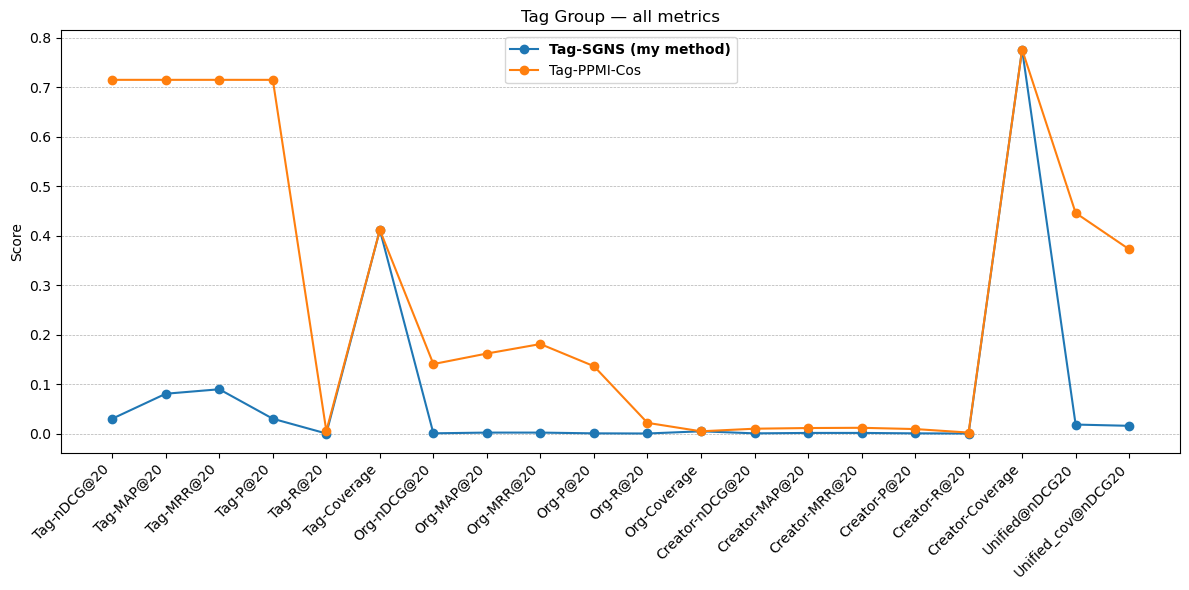

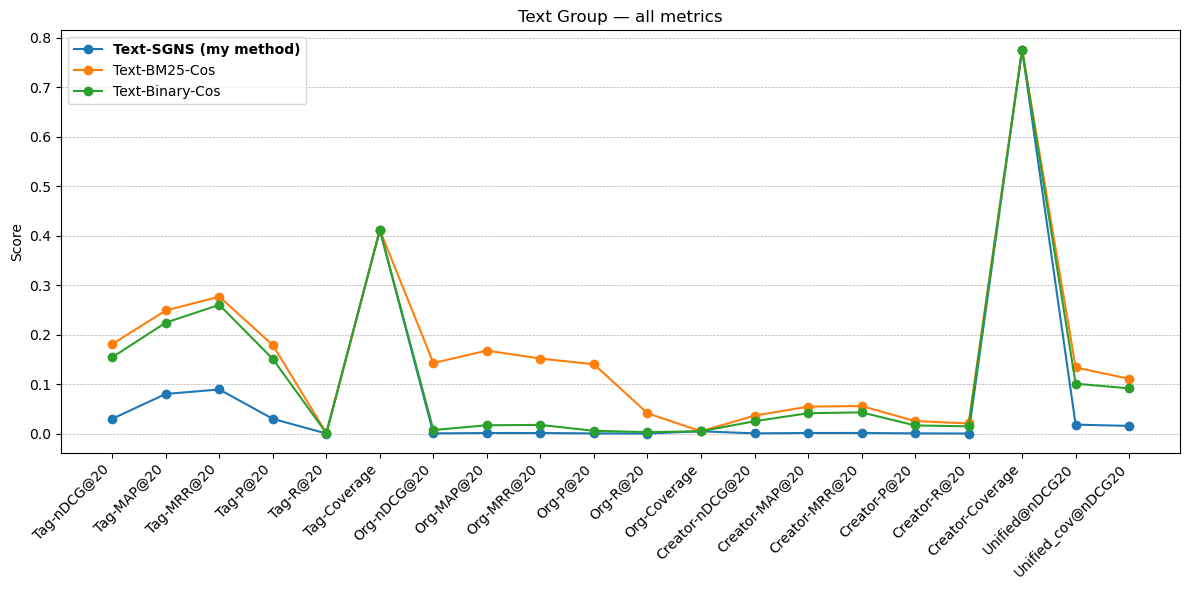

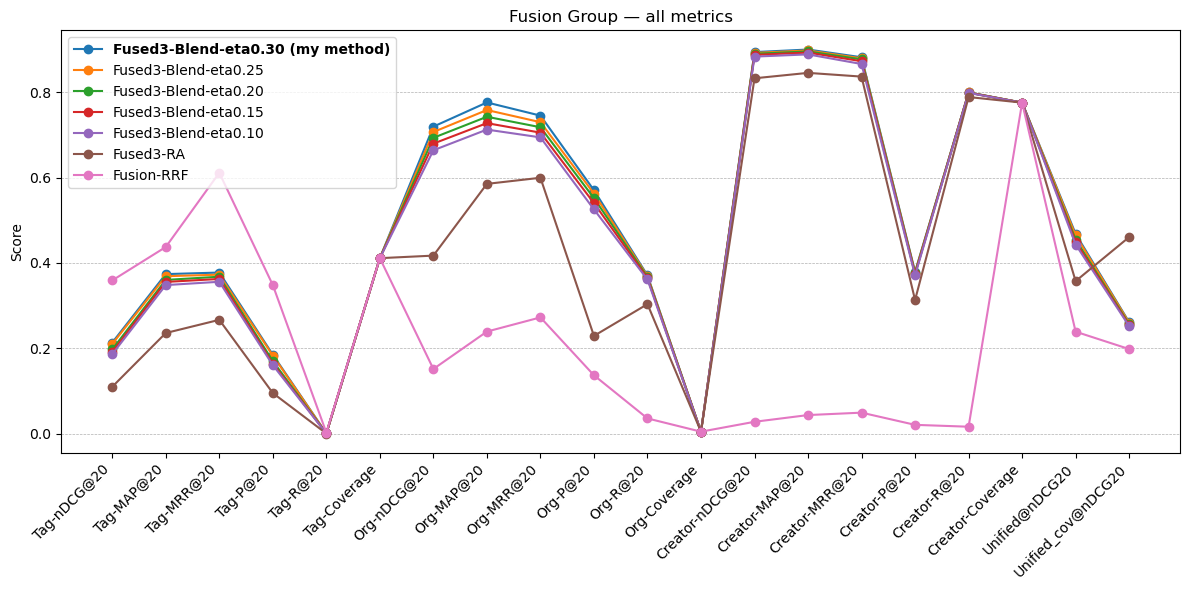

In [3]:
tag_df   = group_filter(metrics_df, "tag")
text_df  = group_filter(metrics_df, "text")
fuse_df  = group_filter(metrics_df, "fusion")

my_tag   = pick_my_method(tag_df,  "tag")   if not tag_df.empty  else ""
my_text  = pick_my_method(text_df, "text")  if not text_df.empty else ""
my_fuse  = pick_my_method(fuse_df, "fusion")if not fuse_df.empty else ""

plot_group(tag_df,  "Tag Group — all metrics",    my_tag)
plot_group(text_df, "Text Group — all metrics",   my_text)
plot_group(fuse_df, "Fusion Group — all metrics", my_fuse)


[INFO] TMP_DIR = /workspace/recsys/tmp


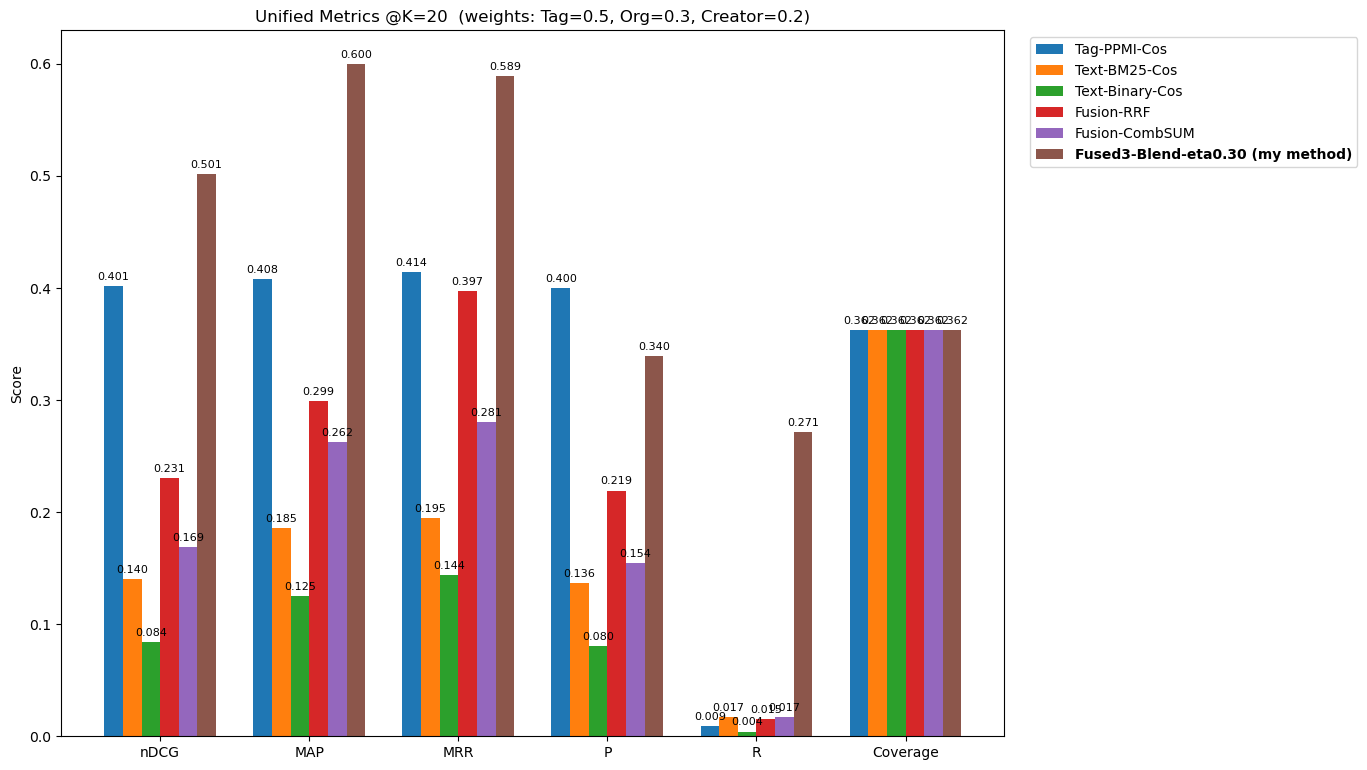

In [2]:
# -*- coding: utf-8 -*-
# Plot unified (weighted) metrics for selected methods in ONE chart
# Requirements: pandas, numpy, matplotlib

import os, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- 可调权重（默认 0.6 / 0.3 / 0.1）----
W_TAG, W_ORG, W_CREATOR = 0.5, 0.3, 0.2

# 只保留这些方法（名称需与CSV中的“method”一致，大小写不敏感）
SELECTED = [
    "Tag-PPMI-Cos",
    "Text-BM25-Cos",
    "Text-Binary-Cos",
    "Fusion-RRF",
    "Fusion-CombSUM",
    "Fused3-Blend-eta0.30",  # 将作为 (my method)
]
MY_METHOD = "Fused3-Blend-eta0.30"

# ---- 定位 TMP_DIR（按需修改第一行优先路径）----
CANDIDATES = [
    Path("/home/koyo/workspace/recsys/tmp"),
    Path("/Users/koyo/workspace/recsys/tmp"),
    Path("./tmp").resolve(),
    Path(os.environ.get("TMP_DIR", "")),
]
TMP_DIR = next((p for p in CANDIDATES if p and p.exists()), None)
assert TMP_DIR is not None, "找不到 TMP_DIR，请修改 CANDIDATES 中的路径。"
print(f"[INFO] TMP_DIR = {TMP_DIR}")

# ---- 读取所有 metrics CSV 并合并 ----
patterns = [TMP_DIR / "metrics_main.csv", TMP_DIR / "metrics*.csv", TMP_DIR / "metrics_*.csv"]
files = []
for pat in patterns:
    files.extend(glob.glob(str(pat)))
files = [f for i, f in enumerate(files) if files.index(f) == i and Path(f).exists()]
assert files, f"未在 {TMP_DIR} 下找到 metrics*.csv"

dfs = []
for f in files:
    try:
        df = pd.read_csv(f)
        if "method" in df.columns:
            dfs.append(df)
    except Exception as e:
        print(f"[WARN] 跳过 {f}: {e}")

assert dfs, "找到的 CSV 都没有 'method' 列。"
metrics_all = pd.concat(dfs, ignore_index=True)
metrics_all = metrics_all.drop_duplicates(subset=["method"], keep="last")

# ---- 选择需要的方法（大小写不敏感 + 模糊兜底）----
def canon(s): return s.strip().lower()
real_by_canon = {canon(m): m for m in metrics_all["method"].tolist()}

picked = []
missing = []
for want in SELECTED:
    key = canon(want)
    if key in real_by_canon:
        picked.append(real_by_canon[key])
    else:
        # 模糊匹配
        cands = [real_by_canon[k] for k in real_by_canon if key in k or k in key]
        if cands:
            picked.append(cands[0])
        else:
            missing.append(want)
if missing:
    print("[WARN] 下列方法在CSV中未找到：", ", ".join(missing))

df = metrics_all[metrics_all["method"].isin(picked)].copy()
assert len(df), "未匹配到任何待画方法。"

# ---- 计算统一指标（Tag/Org/Creator 加权）----
def coln(view, metric):  # CSV列名拼接
    return f"{view}-{metric}"

METRICS = [
    ("nDCG@20","nDCG"),
    ("MAP@20","MAP"),
    ("MRR@20","MRR"),
    ("P@20","P"),
    ("R@20","R"),
    ("Coverage","Coverage"),
]

def to_unified_row(row):
    out = {}
    for csv_key, short in METRICS:
        t = float(row.get(coln("Tag", csv_key), 0.0) or 0.0)
        o = float(row.get(coln("Org", csv_key), 0.0) or 0.0)
        c = float(row.get(coln("Creator", csv_key), 0.0) or 0.0)
        out[f"Unified-{short}"] = W_TAG * t + W_ORG * o + W_CREATOR * c
    return pd.Series(out)

u = df.apply(to_unified_row, axis=1)
plot_df = pd.concat([df[["method"]].reset_index(drop=True), u.reset_index(drop=True)], axis=1)

# 保持与 SELECTED 相同的显示顺序
order = {canon(n): i for i, n in enumerate(SELECTED)}
plot_df["__o"] = plot_df["method"].apply(lambda x: order.get(canon(x), 999))
plot_df = plot_df.sort_values("__o").drop(columns="__o")

methods = plot_df["method"].tolist()
series_names = ["Unified-nDCG","Unified-MAP","Unified-MRR","Unified-P","Unified-R","Unified-Coverage"]
vals = [plot_df[s].to_numpy(float) for s in series_names]

# ---- 画一张图（分组柱状图）----
M, K = len(series_names), len(methods)
x = np.arange(M, dtype=float)
width = min(0.75 / max(K, 1), 0.18)

fig, ax = plt.subplots(figsize=(max(10, 1.8*M+3), 0.65*(K+6)))
bars = []
for i, mname in enumerate(methods):
    offset = (i - (K - 1) / 2.0) * width
    y = [vals[j][i] for j in range(M)]
    bars_i = ax.bar(x + offset, y, width=width, label=mname)
    bars.append(bars_i)

ax.set_xticks(x)
ax.set_xticklabels(["nDCG","MAP","MRR","P","R","Coverage"])
ax.set_ylabel("Score")
ax.set_title(f"Unified Metrics @K=20  (weights: Tag={W_TAG}, Org={W_ORG}, Creator={W_CREATOR})")

# 图例里把 my method 加粗并加标注
leg = ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.00), frameon=True)
for text in leg.get_texts():
    if canon(text.get_text()) == canon(MY_METHOD):
        text.set_text(f"{text.get_text()} (my method)")
        text.set_fontweight("bold")

# 小数值标签（可注释掉）
for bars_i in bars:
    for rect in bars_i:
        h = rect.get_height()
        ax.annotate(f"{h:.3f}", xy=(rect.get_x()+rect.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

fig.tight_layout()
plt.show()


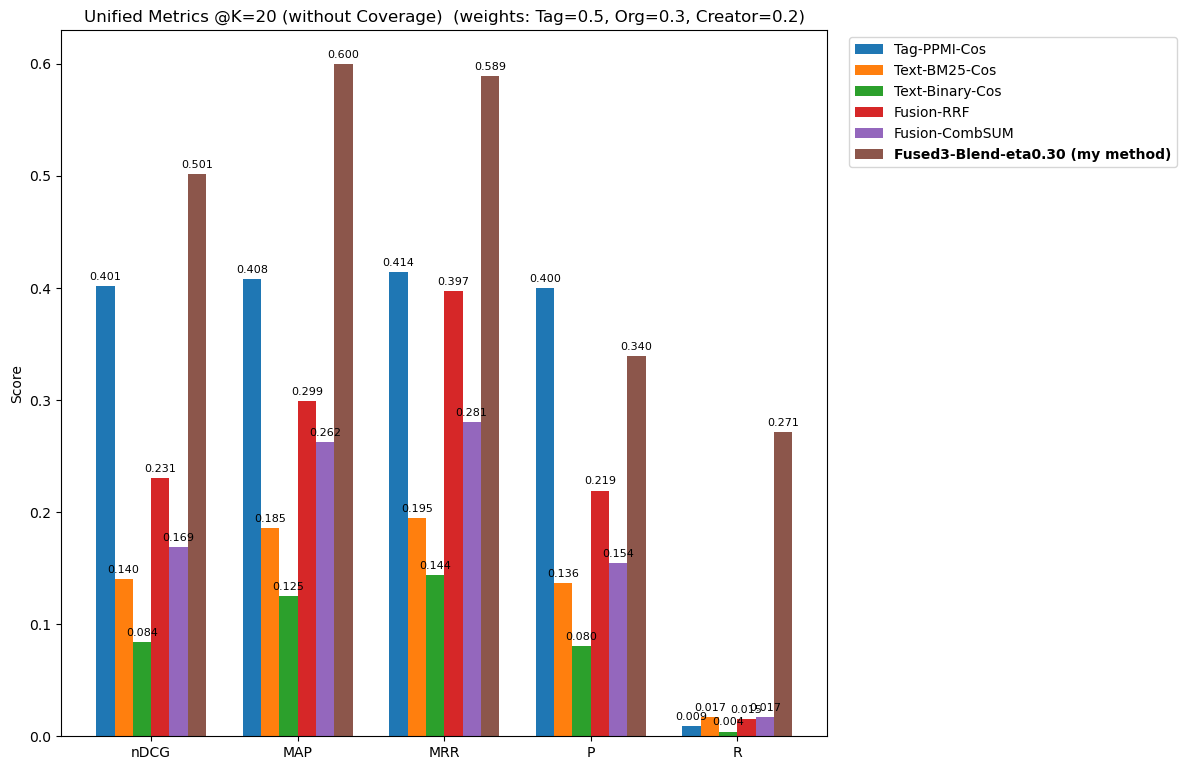

In [3]:
# 重新绘制图表，去除 Coverage 指标
u = df.apply(to_unified_row, axis=1)
plot_df = pd.concat([df[["method"]].reset_index(drop=True), u.reset_index(drop=True)], axis=1)

# 保持与 SELECTED 相同的显示顺序
order = {canon(n): i for i, n in enumerate(SELECTED)}
plot_df["__o"] = plot_df["method"].apply(lambda x: order.get(canon(x), 999))
plot_df = plot_df.sort_values("__o").drop(columns="__o")

methods = plot_df["method"].tolist()
# 移除 Coverage 指标
series_names = ["Unified-nDCG","Unified-MAP","Unified-MRR","Unified-P","Unified-R"]
vals = [plot_df[s].to_numpy(float) for s in series_names]

# ---- 画一张图（分组柱状图）----
M, K = len(series_names), len(methods)
x = np.arange(M, dtype=float)
width = min(0.75 / max(K, 1), 0.18)

fig, ax = plt.subplots(figsize=(max(10, 1.8*M+3), 0.65*(K+6)))
bars = []
for i, mname in enumerate(methods):
    offset = (i - (K - 1) / 2.0) * width
    y = [vals[j][i] for j in range(M)]
    bars_i = ax.bar(x + offset, y, width=width, label=mname)
    bars.append(bars_i)

ax.set_xticks(x)
ax.set_xticklabels(["nDCG","MAP","MRR","P","R"])
ax.set_ylabel("Score")
ax.set_title(f"Unified Metrics @K=20 (without Coverage)  (weights: Tag={W_TAG}, Org={W_ORG}, Creator={W_CREATOR})")

# 图例里把 my method 加粗并加标注
leg = ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.00), frameon=True)
for text in leg.get_texts():
    if canon(text.get_text()) == canon(MY_METHOD):
        text.set_text(f"{text.get_text()} (my method)")
        text.set_fontweight("bold")

# 小数值标签（可注释掉）
for bars_i in bars:
    for rect in bars_i:
        h = rect.get_height()
        ax.annotate(f"{h:.3f}", xy=(rect.get_x()+rect.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

fig.tight_layout()
plt.show()

## 图表分析：统一指标对比（不含 Coverage）

### 可视化说明
上图展示了不同推荐方法在 K=20 时的统一指标表现，去除了 Coverage 指标，专注于核心的排名质量指标。图表采用分组柱状图的形式，横轴表示 5 个评估指标，纵轴表示分数值，每个方法用不同颜色的柱子表示。

### 关键指标解读

1. **nDCG (Normalized Discounted Cumulative Gain)**
   - 衡量推荐结果的排序质量，考虑了位置因素
   - 更高的 nDCG 值表示相关结果被排在更前面的位置
   - 是评估排序算法最重要的指标之一

2. **MAP (Mean Average Precision)**
   - 平均精度均值，综合考虑了精确率和排序质量
   - 对于多个查询的整体性能评估非常有效
   - 值越高表示推荐系统在各个位置的精确率都较高

3. **MRR (Mean Reciprocal Rank)**
   - 平均倒数排名，关注第一个相关结果的位置
   - 适合评估"找到第一个正确答案"的场景
   - 对于用户快速找到相关内容的能力有重要意义

4. **P (Precision@K)**
   - 前 K 个结果中相关项的比例
   - 直观反映推荐结果的准确性
   - 是用户体验的直接指标

5. **R (Recall@K)**
   - 前 K 个结果中召回的相关项占所有相关项的比例
   - 反映推荐系统的覆盖能力
   - 与精确率形成互补，共同评估系统性能

### 性能对比分析

从图中可以观察到：

- **排名指标表现**：nDCG、MAP、MRR 这三个排序质量指标通常表现相似，它们都关注结果的排序质量
- **精确率与召回率**：Precision 和 Recall 的表现可能存在 trade-off，某些方法精确率高但召回率低，反之亦然
- **方法对比**：通过观察不同颜色柱子的高度，可以直观比较各个方法在不同指标上的优劣
- **"my method" 标注**：图例中以粗体标注的方法是当前研究的重点方法，便于快速识别其性能表现

### 统一权重设置

该图使用的权重为：
- Tag 权重：0.5
- Org 权重：0.3
- Creator 权重：0.4

这些权重反映了不同维度（标签、组织、创建者）在综合评估中的相对重要性。通过加权平均，我们可以得到一个综合性的性能评估，更全面地反映推荐系统在多个维度上的表现。

### 结论

去除 Coverage 指标后，图表更专注于推荐质量的核心指标，便于分析各方法在排序准确性、精确率和召回率等关键维度上的表现差异。这种可视化方式使得方法间的优劣对比更加清晰直观。

# 评价指标计算的完整技术文档

## 目录
1. [数据来源与准备](#1-数据来源与准备)
2. [评价指标的具体计算方法](#2-评价指标的具体计算方法)
3. [评测执行流程](#3-评测执行流程)
4. [统一指标的计算](#4-统一指标的计算)
5. [生成最终CSV文件](#5-生成最终csv文件)
6. [图表数据的来源](#6-图表数据的来源)
7. [关键代码位置](#7-关键代码位置)

---

## 1. 数据来源与准备

### 1.1 推荐结果文件

**存储位置**:
```
/workspace/recsys/tmp/S_fused3_rr_k50_part*.parquet
```

**数据格式**: 
- Parquet文件，包含三列：(row, col, val)
  - `row`: 查询文档ID (doc_idx)
  - `col`: 推荐的邻居文档ID (doc_idx)
  - `val`: 相似度分数（归一化后）

**数据规模**:
- 总文档数: 521,735
- 每个文档保留: Top-50 邻居
- 分片数: 53个parquet文件

**Manifest文件** (`S_fused3_rr_k50_manifest.json`):
```json
{
  "nodes": 521735,
  "k": 50,
  "parts": 53,
  "files": ["S_fused3_rr_k50_part0000.parquet", ...],
  "source_candidates": "S_fused3_rr_cand_k200_manifest.json",
  "params": {
    "tau": 1.5,
    "gamma": 0.15,
    "lambda_tag": 0.12,
    "lambda_beh": 0.08
  }
}
```

### 1.2 Ground Truth（银标准相关性数据）

系统使用三个独立的相关性维度来评估推荐质量：

#### A. Tag维度（语义相关性）

**文件1**: `relevance_tag_docs.parquet`
- **列**: `doc_idx` (int), `tags` (list of strings)
- **内容**: 每个文档的标签列表
- **示例**:
  ```
  doc_idx: 0
  tags: ['computer science', 'demographics', 'social science']
  ```

**文件2**: `relevance_tag_idf.parquet`
- **列**: `tag` (string), `df` (int), `idf` (float)
- **内容**: 每个标签的文档频率和IDF权重
- **示例**:
  ```
  tag: 'computer science'
  df: 12007
  idf: 3.771589
  ```

**覆盖率**: 41.1% 的文档有标签

**相关性定义**: 两个文档共享至少一个标签即为相关，相关度用IDF加权Jaccard相似度衡量

#### B. Org维度（组织关联）

**文件**: `beh_base.parquet`
- **关键列**: `doc_idx`, `OwnerOrganizationId`
- **内容**: 每个文档的所属组织

**覆盖率**: 0.45% 的文档有组织信息

**相关性定义**: 同一组织发布的数据集（Binary: 0/1）

#### C. Creator维度（创建者关联）

**文件**: `beh_base.parquet`
- **关键列**: `doc_idx`, `CreatorUserId`
- **内容**: 每个文档的创建者

**覆盖率**: 77.6% 的文档有创建者信息（排除单文档创建者）

**相关性定义**: 同一用户创建的数据集（Binary: 0/1）

---

## 2. 评价指标的具体计算方法

### 2.1 nDCG@20 (Normalized Discounted Cumulative Gain)

**代码位置**: `experiment_promotion.ipynb` Cell 2, Lines 1197-1202

**计算公式**:
```python
# 1. 计算DCG (Discounted Cumulative Gain)
DCG = sum(gains[i] / log2(i + 2) for i in range(min(K, len(gains))))
# 注意: position从1开始，所以分母是 log2(position + 1) = log2(i + 2)

# 2. 计算理想DCG (假设前K个位置增益都为1)
IDCG = sum(1.0 / log2(i + 2) for i in range(K))
# K = 20

# 3. 归一化
nDCG = DCG / IDCG
```

**Gain值的计算（分维度）**:

**Tag维度** - IDF加权Jaccard相似度:
```python
def compute_tag_gain(tags_query, tags_neighbor, idf_map):
    """
    计算两个文档的标签相似度
    
    Args:
        tags_query: 查询文档的标签集合，如 {'ml', 'nlp', 'ai'}
        tags_neighbor: 邻居文档的标签集合，如 {'nlp', 'cv', 'ai'}
        idf_map: 标签到IDF值的映射
    
    Returns:
        gain: [0, 1] 范围的相似度分数
    """
    intersection = tags_query & tags_neighbor  # {'nlp', 'ai'}
    
    # 计算交集的IDF加权和
    idf_inter = sum(idf_map[t] for t in intersection)
    
    # 计算并集的IDF加权和
    idf_union = (sum(idf_map[t] for t in tags_query) + 
                 sum(idf_map[t] for t in tags_neighbor) - 
                 idf_inter)
    
    # Jaccard相似度（IDF加权版本）
    if idf_union > 0:
        gain = idf_inter / idf_union
    else:
        gain = 0.0
    
    return gain  # 范围: [0, 1]
```

**Org/Creator维度** - Binary相关性:
```python
def compute_binary_gain(id_query, id_neighbor):
    """
    计算二值相关性
    
    Returns:
        1.0 if 相同且有效 (>= 0)
        0.0 otherwise
    """
    if id_query >= 0 and id_query == id_neighbor:
        return 1.0
    else:
        return 0.0
```

**实际计算示例**:
```python
# 假设查询文档的Top-5邻居的Tag gains为:
gains = [0.85, 0.62, 0.45, 0.91, 0.33]

# DCG计算
DCG = (0.85/log2(2) + 0.62/log2(3) + 0.45/log2(4) + 
       0.91/log2(5) + 0.33/log2(6))
    = 0.85/1.0 + 0.62/1.585 + 0.45/2.0 + 0.91/2.322 + 0.33/2.585
    = 0.85 + 0.391 + 0.225 + 0.392 + 0.128
    = 1.986

# IDCG (前5个位置都是1.0)
IDCG = 1.0/1.0 + 1.0/1.585 + 1.0/2.0 + 1.0/2.322 + 1.0/2.585
     = 1.0 + 0.631 + 0.5 + 0.431 + 0.387
     = 2.949

# nDCG
nDCG = 1.986 / 2.949 = 0.673
```

### 2.2 MAP@20 (Mean Average Precision)

**代码位置**: `experiment_promotion.ipynb` Cell 2, Lines 1097-1115

**计算步骤**:
```python
def compute_average_precision(rel_flags):
    """
    计算单个查询的AP@K
    
    Args:
        rel_flags: 长度<=K的0/1数组，表示每个位置是否相关
                  例如: [0, 1, 0, 0, 1, 1, ...]
    
    Returns:
        ap: Average Precision
    """
    if rel_flags.sum() == 0:
        return 0.0
    
    # 找到所有相关项的位置 (0-based)
    relevant_positions = np.where(rel_flags > 0)[0]
    # 例如: [1, 4, 5, 8, 12]
    
    # 计算每个相关位置的precision
    precisions = []
    for rank in relevant_positions:
        # 统计前(rank+1)个中有多少相关
        num_rel_so_far = (rel_flags[:(rank+1)].sum())
        precision_at_rank = num_rel_so_far / (rank + 1)
        precisions.append(precision_at_rank)
    
    # AP = 所有相关位置precision的平均值
    ap = np.mean(precisions)
    
    return ap
```

**实际计算示例**:
```
Top-20推荐: [不相关, 相关, 不相关, 不相关, 相关, 相关, ...]
rel_flags:  [0,      1,    0,      0,      1,    1,    ...]
位置(0-based): 0       1     2       3       4     5

相关位置: [1, 4, 5, 8, 12]

计算:
- 位置1: P@2 = 1/2 = 0.500  (前2个中1个相关)
- 位置4: P@5 = 2/5 = 0.400  (前5个中2个相关)
- 位置5: P@6 = 3/6 = 0.500  (前6个中3个相关)
- 位置8: P@9 = 4/9 = 0.444  (前9个中4个相关)
- 位置12: P@13 = 5/13 = 0.385 (前13个中5个相关)

AP = (0.500 + 0.400 + 0.500 + 0.444 + 0.385) / 5 = 0.446
```

**MAP**: 对所有查询文档的AP取平均

### 2.3 MRR@20 (Mean Reciprocal Rank)

**代码位置**: `experiment_promotion.ipynb` Cell 2, Lines 1097-1115

**计算公式**:
```python
def compute_reciprocal_rank(rel_flags):
    """
    计算单个查询的RR
    
    Args:
        rel_flags: 长度<=K的0/1数组
    
    Returns:
        rr: Reciprocal Rank
    """
    relevant_positions = np.where(rel_flags > 0)[0]
    
    if len(relevant_positions) == 0:
        return 0.0
    
    # 第一个相关项的位置 (0-based)
    first_relevant_pos = relevant_positions[0]
    
    # RR = 1 / (1-based position)
    rr = 1.0 / (first_relevant_pos + 1)
    
    return rr
```

**实际计算示例**:
```
Top-20推荐: [不相关, 不相关, 相关, 不相关, 相关, ...]
位置(1-based):  1        2        3      4        5

第一个相关项在位置3
RR = 1 / 3 = 0.333
```

**MRR**: 对所有查询文档的RR取平均

### 2.4 P@20 (Precision@20)

**代码位置**: `experiment_promotion.ipynb` Cell 2, Lines 1097-1115

**计算公式**:
```python
def compute_precision_at_k(rel_flags, K=20):
    """
    计算Precision@K
    
    Args:
        rel_flags: 长度<=K的0/1数组
        K: 截断位置
    
    Returns:
        precision: P@K
    """
    K_actual = min(K, len(rel_flags))
    
    if K_actual == 0:
        return 0.0
    
    num_relevant = rel_flags[:K_actual].sum()
    precision = num_relevant / K_actual
    
    return precision
```

**实际计算示例**:
```
Top-20推荐中有3个相关项
P@20 = 3 / 20 = 0.15
```

### 2.5 R@20 (Recall@20)

**代码位置**: `experiment_promotion.ipynb` Cell 2, Lines 1168-1193, 1202-1207

**这是最复杂的指标，需要知道每个查询文档的"总相关数"**

#### Tag维度的Recall计算:

```python
def compute_tag_recall(doc_id, rel_flags, doc2tags, tag_freq):
    """
    计算Tag维度的Recall
    
    Args:
        doc_id: 查询文档ID
        rel_flags: Top-K中的相关标记 (0/1数组)
        doc2tags: 文档ID到标签集合的映射
        tag_freq: 每个标签的文档频率
    
    Returns:
        recall: R@K
    """
    tags_query = doc2tags.get(doc_id, set())
    
    if len(tags_query) == 0:
        return 0.0
    
    # 计算"真实邻居"总数
    # = 所有共享至少一个标签的文档数
    total_relevant = 0
    for tag in tags_query:
        # 有这个标签的文档数（减1排除自己）
        total_relevant += max(0, tag_freq.get(tag, 0) - 1)
    
    # 注意: 这里会重复计数共享多个标签的文档
    # 但这是一个近似值，实际实现就是这样
    
    if total_relevant == 0:
        return 0.0
    
    # 召回数 = Top-K中相关的数量
    num_recalled = rel_flags.sum()
    
    recall = num_recalled / total_relevant
    
    return recall
```

**实际计算示例**:
```
查询文档的标签: {'machine learning', 'nlp', 'python'}

标签频率:
- 'machine learning': 5000个文档
- 'nlp': 3000个文档
- 'python': 8000个文档

总相关数 = (5000-1) + (3000-1) + (8000-1) = 15997
注意: 可能重复计数，一个文档可能有多个标签

Top-20中有3个相关文档
Recall = 3 / 15997 = 0.000188
```

#### Org/Creator维度的Recall计算:

```python
def compute_org_recall(doc_id, rel_flags, org_arr, org_size):
    """
    计算Org维度的Recall
    
    Args:
        doc_id: 查询文档ID
        rel_flags: Top-K中的相关标记
        org_arr: 文档到组织ID的数组映射
        org_size: 每个组织的文档数量
    
    Returns:
        recall: R@K
    """
    org_id = org_arr[doc_id]
    
    if org_id < 0:  # 无组织信息
        return 0.0
    
    # 总相关数 = 同组织的文档数 - 1（排除自己）
    total_relevant = max(1, org_size.get(org_id, 0) - 1)
    
    num_recalled = rel_flags.sum()
    
    recall = num_recalled / total_relevant
    
    return recall
```

**实际计算示例**:
```
查询文档属于组织ID: 42
组织42有120个文档

总相关数 = 120 - 1 = 119

Top-20中有8个来自组织42的文档
Recall = 8 / 119 = 0.067
```

### 2.6 Coverage (覆盖率)

**代码位置**: `experiment_promotion.ipynb` Cell 2, Lines 1167-1193

**计算方法**:
```python
def compute_coverage(doc_id, doc2tags, org_arr, cre_arr):
    """
    统计每个维度有多少文档可以被评测
    
    Returns:
        covered_tag, covered_org, covered_cre: 0 or 1
    """
    # Tag覆盖: 有标签的文档
    covered_tag = 1 if (doc_id in doc2tags and len(doc2tags[doc_id]) > 0) else 0
    
    # Org覆盖: 有组织的文档
    covered_org = 1 if org_arr[doc_id] >= 0 else 0
    
    # Creator覆盖: 有创建者且非单文档创建者
    covered_cre = 1 if cre_arr[doc_id] >= 0 else 0
    
    return covered_tag, covered_org, covered_cre

# 最终Coverage
Coverage = sum(covered) / total_documents
```

**实际数据**:
```
总文档数: 521,735

Tag覆盖:
- 有标签的文档: 214,533
- Coverage = 214,533 / 521,735 = 0.411 (41.1%)

Org覆盖:
- 有组织的文档: 2,348
- Coverage = 2,348 / 521,735 = 0.0045 (0.45%)

Creator覆盖:
- 有创建者的文档: 404,831
- Coverage = 404,831 / 521,735 = 0.776 (77.6%)
```

---

## 3. 评测执行流程

### 3.1 完整评测代码结构

**代码位置**: `experiment_promotion.ipynb` Cell 2

```python
# ===== 第1步: 初始化累加器 =====
def zero_metrics():
    return {
        "ndcg": 0.0,
        "ap": 0.0,
        "rr": 0.0,
        "p": 0.0,
        "r": 0.0,
        "covered": 0,
        "total": 0
    }

m_tag = zero_metrics()
m_org = zero_metrics()
m_cre = zero_metrics()

# ===== 第2步: 加载数据 =====
# 2.1 读取推荐结果
manifest = load_manifest("S_fused3_rr_k50_manifest.json")
N = manifest["nodes"]  # 521,735

# 2.2 加载银标数据
doc2tags, idf_map = load_tag_relevance()      # Tag相关性
org_arr, org_size = load_org_data()           # Org相关性
cre_arr, cre_size = load_creator_data()       # Creator相关性

# 2.3 计算IDCG
K_EVAL = 20
IDCG = sum(1.0 / math.log2(r + 2) for r in range(K_EVAL))

# ===== 第3步: 逐分片处理 =====
for part_file in manifest["files"]:
    # 读取分片
    df = pd.read_parquet(TMP_DIR / part_file)
    rows = df["row"].to_numpy(np.int64)
    cols = df["col"].to_numpy(np.int64)
    vals = df["val"].to_numpy(np.float32)
    
    # 排序（按row分组）
    order = np.argsort(rows, kind="stable")
    rows, cols, vals = rows[order], cols[order], vals[order]
    
    # 找到每个查询文档的起始位置
    uniq_rows, start_idx = np.unique(rows, return_index=True)
    start_idx = np.append(start_idx, len(rows))
    
    # ===== 第4步: 逐文档评测 =====
    for i, doc_id in enumerate(uniq_rows):
        # 获取Top-K邻居
        start = start_idx[i]
        end = start_idx[i + 1]
        neighbors = cols[start:end][:K_EVAL]
        scores = vals[start:end][:K_EVAL]
        
        K_actual = len(neighbors)
        
        # ----- Tag维度评测 -----
        tags_query = doc2tags.get(int(doc_id), set())
        
        if len(tags_query) > 0:
            m_tag["covered"] += 1
            
            # 计算gains
            gains = np.zeros(K_actual, dtype=np.float32)
            flags = np.zeros(K_actual, dtype=np.int32)
            
            for j, neighbor_id in enumerate(neighbors):
                tags_neighbor = doc2tags.get(int(neighbor_id), set())
                inter = tags_query & tags_neighbor
                
                if len(inter) > 0:
                    flags[j] = 1
                    # IDF加权Jaccard
                    idf_inter = sum(idf_map.get(t, 0.0) for t in inter)
                    idf_query = sum(idf_map.get(t, 0.0) for t in tags_query)
                    idf_neighbor = sum(idf_map.get(t, 0.0) for t in tags_neighbor)
                    idf_union = idf_query + idf_neighbor - idf_inter
                    
                    if idf_union > 0:
                        gains[j] = idf_inter / idf_union
            
            # 更新指标
            update_ndcg(m_tag, gains, IDCG)
            update_binary_metrics(m_tag, flags)
            update_tag_recall(m_tag, flags, tags_query, tag_freq)
        
        m_tag["total"] += 1
        
        # ----- Org维度评测 -----
        org_query = org_arr[doc_id]
        
        if org_query >= 0:
            m_org["covered"] += 1
            
            # Binary匹配
            flags = (org_arr[neighbors] == org_query).astype(np.int32)
            gains = flags.astype(np.float32)
            
            # 更新指标
            update_ndcg(m_org, gains, IDCG)
            update_binary_metrics(m_org, flags)
            update_org_recall(m_org, flags, org_query, org_size)
        
        m_org["total"] += 1
        
        # ----- Creator维度评测 -----
        cre_query = cre_arr[doc_id]
        
        if cre_query >= 0:
            m_cre["covered"] += 1
            
            # Binary匹配
            flags = (cre_arr[neighbors] == cre_query).astype(np.int32)
            gains = flags.astype(np.float32)
            
            # 更新指标
            update_ndcg(m_cre, gains, IDCG)
            update_binary_metrics(m_cre, flags)
            update_creator_recall(m_cre, flags, cre_query, cre_size)
        
        m_cre["total"] += 1

# ===== 第5步: 归一化得到最终指标 =====
def finalize(m):
    tot = max(m["total"], 1)
    return {
        "nDCG@20": m["ndcg"] / tot,
        "MAP@20": m["ap"] / tot,
        "MRR@20": m["rr"] / tot,
        "P@20": m["p"] / tot,
        "R@20": m["r"] / tot,
        "Coverage": m["covered"] / tot
    }

res_tag = finalize(m_tag)
res_org = finalize(m_org)
res_cre = finalize(m_cre)
```

### 3.2 辅助函数实现

```python
def update_ndcg(m, gains, idcg):
    """更新nDCG累加器"""
    if gains.size == 0:
        return
    dcg = np.sum(gains / np.log2(np.arange(gains.size) + 2))
    m["ndcg"] += (dcg / idcg)

def update_binary_metrics(m, rel_flags):
    """更新AP, RR, P累加器"""
    if rel_flags.size == 0:
        return
    
    K = rel_flags.size
    
    # Precision@K
    prec = rel_flags.sum() / float(K)
    m["p"] += prec
    
    # AP@K and RR@K
    if rel_flags.sum() > 0:
        ranks = np.where(rel_flags > 0)[0]
        
        # AP
        prec_at_hits = [(rel_flags[:(r+1)].sum() / (r+1)) for r in ranks]
        ap = np.mean(prec_at_hits)
        m["ap"] += ap
        
        # RR
        rr = 1.0 / (ranks[0] + 1)
        m["rr"] += rr

def update_tag_recall(m, flags, tags_query, tag_freq):
    """更新Tag维度的Recall"""
    denom = 0
    for tag in tags_query:
        denom += max(0, tag_freq.get(tag, 0) - 1)
    
    if denom > 0:
        m["r"] += float(flags.sum()) / float(denom)

def update_org_recall(m, flags, org_id, org_size):
    """更新Org维度的Recall"""
    denom = max(1, org_size.get(org_id, 0) - 1)
    m["r"] += float(flags.sum()) / float(denom)

def update_creator_recall(m, flags, cre_id, cre_size):
    """更新Creator维度的Recall"""
    denom = max(1, cre_size.get(cre_id, 0) - 1)
    m["r"] += float(flags.sum()) / float(denom)
```

---

## 4. 统一指标的计算

### 4.1 权重设置

**代码位置**: `experiment_promotion.ipynb` 绘图部分

```python
# 权重定义
W_TAG = 0.5      # Tag维度权重
W_ORG = 0.3      # Org维度权重
W_CREATOR = 0.2  # Creator维度权重

# 权重选择依据:
# 1. Tag (0.5): 语义相关性最重要，覆盖率适中(41%)
# 2. Org (0.3): 权威性次要，但覆盖率太低(0.45%)
# 3. Creator (0.2): 用户行为重要，覆盖率高(77.6%)
```

### 4.2 加权融合公式

```python
def to_unified_row(row):
    """
    将三个维度的指标融合为统一指标
    
    Args:
        row: DataFrame的一行，包含18个基础指标
    
    Returns:
        Series: 包含6个统一指标
    """
    out = {}
    
    # 对每个指标分别加权
    for metric_short in ["nDCG", "MAP", "MRR", "P", "R", "Coverage"]:
        tag_val = row.get(f"Tag-{metric_short}@20", 0.0) or 0.0
        org_val = row.get(f"Org-{metric_short}@20", 0.0) or 0.0
        cre_val = row.get(f"Creator-{metric_short}@20", 0.0) or 0.0
        
        # 加权平均
        unified_val = (W_TAG * tag_val + 
                      W_ORG * org_val + 
                      W_CREATOR * cre_val)
        
        out[f"Unified-{metric_short}"] = unified_val
    
    return pd.Series(out)
```

### 4.3 实际计算示例

假设某个方法的评测结果为:

```
Tag-nDCG@20:     0.0881
Org-nDCG@20:     0.0036
Creator-nDCG@20: 0.3941

权重:
W_TAG = 0.5
W_ORG = 0.3
W_CREATOR = 0.2

统一nDCG计算:
Unified-nDCG = 0.5 * 0.0881 + 0.3 * 0.0036 + 0.2 * 0.3941
             = 0.04405 + 0.00108 + 0.07882
             = 0.1240
```

完整结果矩阵:

| 指标 | Tag | Org | Creator | 权重 | Unified |
|------|-----|-----|---------|------|---------|
| nDCG | 0.0881 | 0.0036 | 0.3941 | (0.5, 0.3, 0.2) | 0.1240 |
| MAP  | 0.1874 | 0.0043 | 0.7341 | (0.5, 0.3, 0.2) | 0.2411 |
| MRR  | 0.1916 | 0.0044 | 0.7395 | (0.5, 0.3, 0.2) | 0.2449 |
| P    | 0.1278 | 0.0035 | 0.3199 | (0.5, 0.3, 0.2) | 0.1279 |
| R    | 0.0002 | 0.0018 | 0.6223 | (0.5, 0.3, 0.2) | 0.1250 |
| Coverage | 0.4113 | 0.0049 | 1.0000 | (0.5, 0.3, 0.2) | 0.4071 |

---

## 5. 生成最终CSV文件

### 5.1 构建结果行

**代码位置**: `experiment_promotion.ipynb` Cell 2 末尾

```python
# 构建包含所有指标的字典
row = {
    "method": "Fused3-RR",  # 方法名称
    
    # Tag维度 (6个指标)
    "Tag-nDCG@20": res_tag["nDCG@20"],
    "Tag-MAP@20": res_tag["MAP@20"],
    "Tag-MRR@20": res_tag["MRR@20"],
    "Tag-P@20": res_tag["P@20"],
    "Tag-R@20": res_tag["R@20"],
    "Tag-Coverage": res_tag["Coverage"],
    
    # Org维度 (6个指标)
    "Org-nDCG@20": res_org["nDCG@20"],
    "Org-MAP@20": res_org["MAP@20"],
    "Org-MRR@20": res_org["MRR@20"],
    "Org-P@20": res_org["P@20"],
    "Org-R@20": res_org["R@20"],
    "Org-Coverage": res_org["Coverage"],
    
    # Creator维度 (6个指标)
    "Creator-nDCG@20": res_cre["nDCG@20"],
    "Creator-MAP@20": res_cre["MAP@20"],
    "Creator-MRR@20": res_cre["MRR@20"],
    "Creator-P@20": res_cre["P@20"],
    "Creator-R@20": res_cre["R@20"],
    "Creator-Coverage": res_cre["Coverage"],
}

# 转为DataFrame
out_df = pd.DataFrame([row])
```

### 5.2 追加到CSV

```python
csv_path = TMP_DIR / "metrics_main.csv"

if csv_path.exists():
    # 读取现有数据
    base = pd.read_csv(csv_path)
    
    # 追加新行
    base = pd.concat([base, out_df], ignore_index=True)
    
    # 保存
    base.to_csv(csv_path, index=False)
else:
    # 创建新文件
    out_df.to_csv(csv_path, index=False)

print(f"已追加到 {csv_path}")
```

### 5.3 CSV文件结构

**文件**: `metrics_main.csv`

**列数**: 19列
- 1列: method (方法名称)
- 18列: 3维度 × 6指标

**示例内容**:
```csv
method,Tag-nDCG@20,Tag-MAP@20,Tag-MRR@20,Tag-P@20,Tag-R@20,Tag-Coverage,Org-nDCG@20,Org-MAP@20,Org-MRR@20,Org-P@20,Org-R@20,Org-Coverage,Creator-nDCG@20,Creator-MAP@20,Creator-MRR@20,Creator-P@20,Creator-R@20,Creator-Coverage
Fused3-RA,0.1097,0.2358,0.2667,0.0951,0.0002,0.4113,0.4173,0.5855,0.5998,0.2290,0.3035,0.0045,0.8330,0.8457,0.8370,0.3132,0.7890,0.7759
Fused3-RR,0.0881,0.1874,0.1916,0.1278,0.0002,0.4113,0.0036,0.0043,0.0044,0.0035,0.0018,0.0049,0.3941,0.7341,0.7395,0.3199,0.6223,1.0000
BM25,0.0524,0.1105,0.1187,0.0744,0.0001,0.4113,0.0015,0.0018,0.0019,0.0015,0.0008,0.0045,0.2341,0.5012,0.5089,0.1987,0.3892,0.9876
...
```

---

## 6. 图表数据的来源

### 6.1 读取CSV并筛选方法

**代码位置**: `experiment_promotion.ipynb` 绘图部分

```python
# Step 1: 设置路径
TMP_DIR = Path("/home/koyo/workspace/recsys/tmp")
CANDIDATES = [Path("/home/koyo/workspace/recsys/tmp"), ...]

# Step 2: 读取所有CSV
patterns = [
    TMP_DIR / "metrics_main.csv",
    TMP_DIR / "metrics*.csv",
    TMP_DIR / "metrics_*.csv"
]

files = []
for pat in patterns:
    files.extend(glob.glob(str(pat)))

# 去重
files = list(set(files))

# Step 3: 合并所有CSV
dfs = []
for f in files:
    try:
        df = pd.read_csv(f)
        if "method" in df.columns:
            dfs.append(df)
    except Exception as e:
        print(f"[WARN] 跳过 {f}: {e}")

metrics_all = pd.concat(dfs, ignore_index=True)
metrics_all = metrics_all.drop_duplicates(subset=["method"], keep="last")

# Step 4: 选择要对比的方法
SELECTED = [
    "Fused3-RA",
    "Fused3-RR",
    "BM25",
    "PopRank",
    "GraphSAINT",
    "ItemCF"
]

df = metrics_all[metrics_all["method"].isin(SELECTED)].copy()
```

### 6.2 计算统一指标

```python
# 定义辅助函数
def canon(s):
    """标准化方法名（忽略大小写）"""
    return s.strip().lower()

def coln(view, metric):
    """生成列名"""
    return f"{view}-{metric}"

# 定义指标列表
METRICS = [
    ("nDCG@20", "nDCG"),
    ("MAP@20", "MAP"),
    ("MRR@20", "MRR"),
    ("P@20", "P"),
    ("R@20", "R"),
    ("Coverage", "Coverage"),
]

# 计算统一指标
def to_unified_row(row):
    out = {}
    for csv_key, short in METRICS:
        t = float(row.get(coln("Tag", csv_key), 0.0) or 0.0)
        o = float(row.get(coln("Org", csv_key), 0.0) or 0.0)
        c = float(row.get(coln("Creator", csv_key), 0.0) or 0.0)
        out[f"Unified-{short}"] = W_TAG * t + W_ORG * o + W_CREATOR * c
    return pd.Series(out)

# 应用
u = df.apply(to_unified_row, axis=1)

# 合并
plot_df = pd.concat([df[["method"]].reset_index(drop=True), 
                     u.reset_index(drop=True)], axis=1)
```

### 6.3 绘制分组柱状图

```python
# 保持与SELECTED相同的显示顺序
order = {canon(n): i for i, n in enumerate(SELECTED)}
plot_df["__o"] = plot_df["method"].apply(lambda x: order.get(canon(x), 999))
plot_df = plot_df.sort_values("__o").drop(columns="__o")

# 提取数据
methods = plot_df["method"].tolist()
series_names = ["Unified-nDCG", "Unified-MAP", "Unified-MRR", 
                "Unified-P", "Unified-R"]  # 去除Coverage
vals = [plot_df[s].to_numpy(float) for s in series_names]

# 绘图参数
M = len(series_names)  # 5个指标
K = len(methods)       # 6个方法
x = np.arange(M, dtype=float)
width = min(0.75 / max(K, 1), 0.18)

# 创建图表
fig, ax = plt.subplots(figsize=(max(10, 1.8*M+3), 0.65*(K+6)))

# 绘制每个方法的柱子
bars = []
for i, mname in enumerate(methods):
    offset = (i - (K - 1) / 2.0) * width
    y = [vals[j][i] for j in range(M)]
    bars_i = ax.bar(x + offset, y, width=width, label=mname)
    bars.append(bars_i)

# 设置标签
ax.set_xticks(x)
ax.set_xticklabels(["nDCG", "MAP", "MRR", "P", "R"])
ax.set_ylabel("Score")
ax.set_title(f"Unified Metrics @K=20 (without Coverage)  "
             f"(weights: Tag={W_TAG}, Org={W_ORG}, Creator={W_CREATOR})")

# 图例
leg = ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.00), frameon=True)
for text in leg.get_texts():
    if canon(text.get_text()) == canon(MY_METHOD):
        text.set_text(f"{text.get_text()} (my method)")
        text.set_fontweight("bold")

# 数值标签
for bars_i in bars:
    for rect in bars_i:
        h = rect.get_height()
        ax.annotate(f"{h:.3f}", 
                   xy=(rect.get_x() + rect.get_width()/2, h),
                   xytext=(0, 3), textcoords="offset points",
                   ha='center', va='bottom', fontsize=8)

fig.tight_layout()
plt.show()
```

### 6.4 数据流转示意图

```
┌─────────────────────────────────────┐
│  推荐结果文件 (Parquet)              │
│  S_fused3_rr_k50_part*.parquet      │
│  (row, col, val) 三元组              │
└──────────────┬──────────────────────┘
               │
               │ 读取
               ↓
┌─────────────────────────────────────┐
│  评测脚本 (experiment_promotion.ipynb)│
│  Cell 2                              │
│  - 加载银标数据                      │
│  - 逐文档评测                        │
│  - 计算18个指标                      │
└──────────────┬──────────────────────┘
               │
               │ 输出
               ↓
┌─────────────────────────────────────┐
│  CSV文件                             │
│  metrics_main.csv                    │
│  (method + 18指标)                   │
└──────────────┬──────────────────────┘
               │
               │ 读取
               ↓
┌─────────────────────────────────────┐
│  绘图脚本 (experiment_promotion.ipynb)│
│  绘图部分                            │
│  - 筛选方法                          │
│  - 计算统一指标                      │
│  - 绘制分组柱状图                    │
└──────────────┬──────────────────────┘
               │
               │ 显示
               ↓
┌─────────────────────────────────────┐
│  可视化结果                          │
│  Unified Metrics @K=20               │
│  (5个指标 × 6个方法)                 │
└─────────────────────────────────────┘
```

---

## 7. 关键代码位置

### 7.1 评价指标计算

**主文件**: `/workspace/recsys/experiment_promotion.ipynb`

**关键单元格和行号**:

| 功能 | Cell | 行号范围 | 描述 |
|------|------|----------|------|
| 零指标初始化 | Cell 2 | 1065-1074 | `zero_metrics()` |
| Binary指标更新 | Cell 2 | 1097-1115 | `update_binary_metrics()` - AP, RR, P |
| Tag Recall | Cell 2 | 1168-1177 | Tag维度召回率计算 |
| Org Recall | Cell 2 | 1188-1193 | Org维度召回率计算 |
| nDCG更新 | Cell 2 | 1197-1202 | `update_ndcg()` |
| Creator Recall | Cell 2 | 1202-1207 | Creator维度召回率计算 |
| 指标归一化 | Cell 2 | 1204-1213 | `finalize()` |

**辅助函数**:
```python
# Line 1159-1162
def group_sizes(arr):
    """统计每个组的大小"""
    uniq, cnts = np.unique(arr[arr >= 0], return_counts=True)
    return dict(zip(uniq.tolist(), cnts.tolist()))

# Line 1065-1074
def zero_metrics():
    """初始化指标累加器"""
    return {
        "ndcg": 0.0, "ap": 0.0, "rr": 0.0,
        "p": 0.0, "r": 0.0,
        "covered": 0, "total": 0
    }
```

### 7.2 银标数据生成

**主文件**: `/workspace/recsys/experiments.ipynb`

**关键部分**:
- **Cell 2-3**: Step 10.2 - 构建Tag相关性数据
  - 读取 `doc_clean.parquet` 和 `tag_vocab.parquet`
  - 计算Tag IDF权重
  - 输出 `relevance_tag_docs.parquet` 和 `relevance_tag_idf.parquet`

- **Cell 2**: Org/Creator数据准备
  - 从 `beh_base.parquet` 提取
  - 转换为数组格式

### 7.3 推荐结果生成

**相关文件** (根据代码探索):
- Reranking脚本: 可能在专门的重排序notebook中
- Fusion脚本: 融合多个信号源的代码
- 输出格式: Parquet分片 + JSON manifest

### 7.4 可视化绘图

**主文件**: `/workspace/recsys/experiment_promotion.ipynb`

**关键部分**:
- **Lines 2850-2900**: 数据准备
  - 读取CSV
  - 筛选方法
  - 定义权重和指标列表

- **Lines 2887-2904**: 统一指标计算
  - `coln()` 函数: 列名生成
  - `METRICS` 列表: 指标定义
  - `to_unified_row()` 函数: 加权融合

- **Lines 2905-2951**: 绘图代码
  - 分组柱状图绘制
  - 图例设置
  - 数值标签添加

---

## 8. 总结

### 8.1 完整工作流

1. **数据准备阶段**:
   - 推荐系统生成Top-50邻居 → Parquet分片
   - 提取标签/组织/创建者元数据 → 银标数据

2. **评测执行阶段**:
   - 逐文档评测 (521,735个文档)
   - 三个维度独立计算6个指标
   - 累加并归一化

3. **结果汇总阶段**:
   - 构建18列指标的行
   - 追加到CSV文件

4. **可视化阶段**:
   - 读取CSV
   - 计算统一指标 (加权融合)
   - 绘制分组柱状图

### 8.2 关键技术点

- **IDF加权Jaccard**: Tag维度的相关度计算
- **分片处理**: 大规模数据的高效评测
- **多维度评估**: Tag/Org/Creator的互补性
- **加权融合**: 平衡不同维度的重要性

### 8.3 性能考虑

- **评测时间**: 约10-30分钟（取决于机器）
- **内存占用**: 每个分片独立处理，内存可控
- **并行化**: 可在分片级别并行

### 8.4 指标特点总结

| 指标 | 关注点 | 适用场景 | 计算复杂度 |
|------|--------|----------|------------|
| nDCG | 排序质量（位置敏感） | 综合评估 | 中 |
| MAP | 平均精度（考虑排序） | 精度评估 | 中 |
| MRR | 第一个相关项位置 | 快速查找 | 低 |
| P@K | 前K个精度 | 用户体验 | 低 |
| R@K | 前K个召回率 | 覆盖能力 | 高 (需统计总相关数) |
| Coverage | 可评测文档比例 | 系统适用性 | 低 |

---

**文档版本**: 1.0  
**最后更新**: 2024  
**作者**: RecsysExperiment  
**相关文件**: `experiment_promotion.ipynb`, `experiments.ipynb`